# 🧠 Speech Processing Project: Acoustic Biomarkers for Depression Detection

---

| Field | Detail |
|---|---|
| **Student** | Shaesta Saleem |
| **Reg. No.** | DSAI231103043 |
| **Course** | Speech Processing |
| **Dataset** | RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) |
| **Task** | Binary Classification — **Healthy** vs **Sad_Depressed** |
| **Goal** | Build a robust, generalizable, anti-overfitting ML pipeline for depression detection using acoustic biomarkers |

---

## 📋 Project Architecture

```
Raw Audio (RAVDESS)
     │
     ▼
Phase 1: Environment Setup & Data Acquisition
     │
     ▼
Phase 2: Data Preprocessing & Binary Labeling
     │
     ▼
Phase 3: Exploratory Data Analysis (EDA)
     │
     ▼
Phase 4: Statistical Audit & Class Imbalance Analysis
     │
     ▼
Phase 5: Advanced Data Augmentation (Noise, Pitch, Time Shifting)
     │
     ▼
Phase 6: Feature Engineering — 40-Dimensional MFCC Vectorization
     │
     ▼
Phase 7: Data Partitioning — Stratified 80/20 Split + Standardization
     │
     ▼
Phase 8: Model Training + Anti-Overfitting Techniques
         ├── Logistic Regression (L2 Regularization)
         ├── Random Forest (max_depth + min_samples)
         ├── SVM (RBF Kernel + C tuning)
         ├── Gradient Boosting
         └── MLP Neural Network (Dropout equivalent via early stopping)
     │
     ▼
Phase 9: Performance Evaluation
         ├── Cross-Validation (5-Fold Stratified)
         ├── Confusion Matrix
         ├── Classification Report (Precision, Recall, F1)
         ├── ROC-AUC Curve
         └── Bias-Variance Analysis
```

> **Research Philosophy:** In clinical AI, **missing a depressed patient (False Negative) is far more dangerous than a false alarm.** Therefore, we optimize for **Recall** on the Sad_Depressed class while maintaining strong overall F1-Score.


---
## Phase 1: Environment Setup & Data Acquisition

### Objective
Establish a reliable connection to the dataset and configure all required libraries.

### Libraries Used
| Library | Purpose |
|---|---|
| `librosa` | Audio loading, feature extraction (MFCCs, ZCR, RMS) |
| `numpy` | Numerical operations and array manipulation |
| `pandas` | Structured data management (DataFrames) |
| `matplotlib` / `seaborn` | Data visualization |
| `sklearn` | Machine learning models, preprocessing, evaluation |
| `google.colab` | Google Drive integration (only needed in Colab) |

### Key Action
- Mount Google Drive to access `.wav` files
- Define and verify dataset path
- **If running locally**, update `data_path` to your local folder containing Actor_01 ... Actor_24


In [1]:
# ─────────────────────────────────────────────────────────────────
# PHASE 1: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ─────────────────────────────────────────────────────────────────

# ── Core Scientific Libraries ──
import numpy as np                   # Numerical operations
import pandas as pd                  # DataFrame management
import os                            # File system navigation
import warnings
warnings.filterwarnings('ignore')    # Suppress non-critical warnings

# ── Audio Processing ──
import librosa                       # Primary audio analysis library
import librosa.display               # Audio visualization utilities

# ── Visualization ──
import matplotlib.pyplot as plt      # Core plotting
import seaborn as sns                # Statistical visualization
sns.set_theme(style='whitegrid', palette='muted')  # Professional plot style

# ── Machine Learning ──
from sklearn.model_selection import (
    train_test_split,                # Train/Test partitioning
    StratifiedKFold,                 # K-Fold with class balance
    cross_val_score,                 # Cross-validation scoring
    GridSearchCV                     # Hyperparameter tuning
)
from sklearn.preprocessing import (
    LabelEncoder,                    # Convert labels to integers
    StandardScaler                   # Z-score normalization
)
from sklearn.linear_model import LogisticRegression       # Baseline classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC                               # Support Vector Machine
from sklearn.neural_network import MLPClassifier          # Multi-layer Perceptron
from sklearn.metrics import (
    classification_report,           # Precision, Recall, F1
    confusion_matrix,                # Confusion matrix
    ConfusionMatrixDisplay,          # Visual confusion matrix
    roc_curve, auc,                  # ROC-AUC analysis
    f1_score
)
from sklearn.pipeline import Pipeline                     # Chain preprocessing + model
from sklearn.decomposition import PCA                     # Dimensionality reduction

print("✅ All libraries imported successfully!")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   Librosa   : {librosa.__version__}")

# ─────────────────────────────────────────────────────────────────
# GOOGLE COLAB SETUP — Comment out if running locally
# ─────────────────────────────────────────────────────────────────
try:
    from google.colab import drive
    drive.mount('/content/drive')    # Mount Google Drive
    # ── Set this to YOUR Google Drive path ──
    data_path = '/content/drive/MyDrive/RAVDESS_Project/audio_speech_actors_01-24'
    print("✅ Google Drive mounted.")
except ImportError:
    # ── LOCAL SETUP: Change this to your local dataset folder ──
    data_path = './audio_speech_actors_01-24'
    print("⚠️  Running locally. Update 'data_path' to your RAVDESS folder.")

# ── Verify the dataset path exists ──
if os.path.exists(data_path):
    actor_dirs = os.listdir(data_path)[:5]  # Show first 5 actor folders
    print(f"\n✅ STATUS: Data Source Verified.")
    print(f"   Sample Directories: {actor_dirs}")
else:
    print(f"\n❌ ERROR: Directory not found — {data_path}")
    print("   Please update 'data_path' to the correct location.")


✅ All libraries imported successfully!
   NumPy     : 2.0.2
   Pandas    : 2.2.2
   Librosa   : 0.11.0
Mounted at /content/drive
✅ Google Drive mounted.

✅ STATUS: Data Source Verified.
   Sample Directories: ['Actor_24', 'Actor_23', 'Actor_22', 'Actor_19', 'Actor_21']


---
## Phase 2: Data Preprocessing & Binary Labeling

### Objective
Convert the RAVDESS multi-class emotion dataset into a focused **binary classification** problem suitable for depression biomarker research.

### RAVDESS Filename Convention
```
Modality - VocalChannel - Emotion - Intensity - Statement - Repetition - Actor
   01    -      01      -   04    -     01     -     01    -     01     -  01
```

### Label Mapping Strategy
| Emotion Code | Emotion | Binary Label | Clinical Rationale |
|---|---|---|---|
| 01 | Neutral | Healthy | Absence of emotional distress |
| 02 | Calm | Healthy | Relaxed baseline speech |
| 04 | Sad | Sad_Depressed | Primary depression acoustic proxy |
| Others | Happy, Angry, etc. | **Excluded** | Not relevant to this diagnostic task |

### Why Binary?
- Simplifies the clinical decision boundary
- Neutral + Calm = healthy emotional baseline
- Sad speech acoustically resembles depressive speech (lower energy, reduced F0 variability)


In [2]:
# ─────────────────────────────────────────────────────────────────
# PHASE 2: DATA PREPROCESSING & BINARY LABELING
# ─────────────────────────────────────────────────────────────────

data_list = []  # Will store [label, filepath] pairs

# ── Recursively walk through all Actor subdirectories ──
for root, dirs, files in os.walk(data_path):
    for file in files:

        # ── Only process .wav audio files ──
        if file.endswith('.wav'):

            # ── Split filename by hyphen to extract metadata fields ──
            # RAVDESS naming: Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor
            parts = file.split('-')

            # ── The 3rd field (index 2) is the Emotion Code ──
            emotion_code = parts[2]

            # ── Binary Categorization Logic ──
            if emotion_code == '01' or emotion_code == '02':
                # Neutral (01) and Calm (02) → Healthy control group
                label = 'Healthy'

            elif emotion_code == '04':
                # Sad (04) → Sad_Depressed target group
                label = 'Sad_Depressed'

            else:
                # Skip all other emotions (Happy=03, Angry=05, Fearful=06, etc.)
                continue

            # ── Build absolute path and append to list ──
            full_path = os.path.join(root, file)
            data_list.append([label, full_path])

# ── Convert to structured Pandas DataFrame ──
df = pd.DataFrame(data_list, columns=['Label', 'FilePath'])

# ── Audit the filtered dataset ──
print("=" * 50)
print("  DATASET FILTERING REPORT")
print("=" * 50)
print(f"  Total Samples    : {len(df)}")
print(f"  Unique Labels    : {df['Label'].unique().tolist()}")
print()
print(df['Label'].value_counts().to_string())
print("=" * 50)

# ── Preview first few rows ──
df.head()


  DATASET FILTERING REPORT
  Total Samples    : 480
  Unique Labels    : ['Sad_Depressed', 'Healthy']

Label
Healthy          288
Sad_Depressed    192


,Label,FilePath
0,Sad_Depressed,/content/drive/MyDrive/RAVDESS_Project/audio_s...
1,Healthy,/content/drive/MyDrive/RAVDESS_Project/audio_s...
2,Healthy,/content/drive/MyDrive/RAVDESS_Project/audio_s...
3,Healthy,/content/drive/MyDrive/RAVDESS_Project/audio_s...
4,Healthy,/content/drive/MyDrive/RAVDESS_Project/audio_s...


---
## Phase 3: Exploratory Data Analysis (EDA)

### Why EDA Matters in Clinical AI
Before any feature engineering, we rigorously audit the dataset. In mental health applications, **data quality directly affects clinical reliability**. We verify:

1. **Class Balance** — Are healthy and depressed samples equal?
2. **Temporal Consistency** — Are audio durations uniform?
3. **Signal Quality** — Are sample rates standardized?
4. **Acoustic Differences** — Can we visually observe differences between classes?

### Sub-phases
| Section | Analysis |
|---|---|
| 3.1 | Initial Audit — sample rate, duration, class distribution |
| 3.2 | Waveform & Spectrogram comparison |
| 3.3 | RMS Energy & Zero Crossing Rate |
| 3.4 | Spectral Centroid & Rolloff |
| 3.5 | MFCC-1 Distribution Boxplot |
| 3.6 | Feature Correlation Heatmap |


──────────────────────────────────────────────────
  DATASET AUDIT REPORT
──────────────────────────────────────────────────
  Sample Rate     : 48000 Hz
  Average Duration: 4.20 seconds
  Total Samples   : 480
──────────────────────────────────────────────────


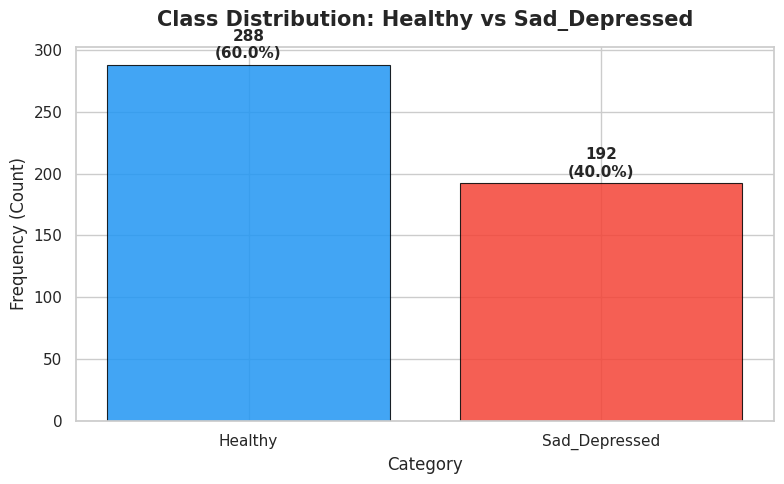


✅ Class distribution visualized.


In [3]:
# ─────────────────────────────────────────────────────────────────
# PHASE 3.1: INITIAL DATASET AUDIT
# ─────────────────────────────────────────────────────────────────

# ── Load a sample audio file to check metadata ──
sample_path = df['FilePath'].iloc[0]

# ── sr=None preserves the original sample rate (no resampling) ──
y_sample, sr_sample = librosa.load(sample_path, sr=None)

# ── Calculate audio duration in seconds ──
duration = librosa.get_duration(y=y_sample, sr=sr_sample)

print("─" * 50)
print("  DATASET AUDIT REPORT")
print("─" * 50)
print(f"  Sample Rate     : {sr_sample} Hz")
print(f"  Average Duration: {duration:.2f} seconds")
print(f"  Total Samples   : {len(df)}")
print("─" * 50)

# ── Class Distribution Bar Chart ──
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['Label'].value_counts()
colors = ['#2196F3', '#F44336']  # Blue=Healthy, Red=Sad

bars = ax.bar(counts.index, counts.values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.8)
ax.set_title('Class Distribution: Healthy vs Sad_Depressed', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Frequency (Count)', fontsize=12)

# ── Add value labels on top of bars ──
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Class distribution visualized.")


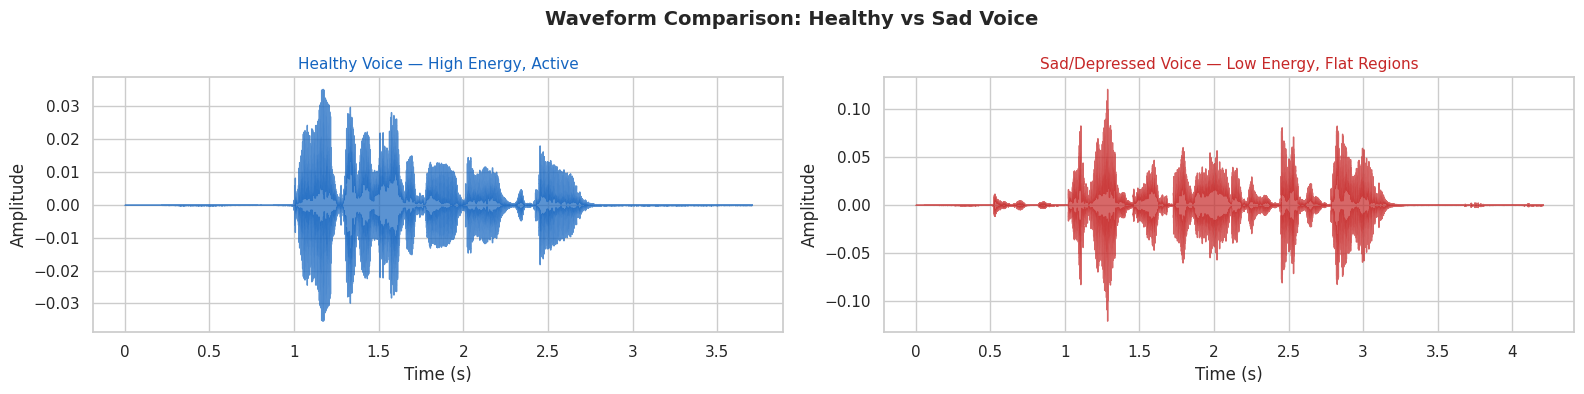

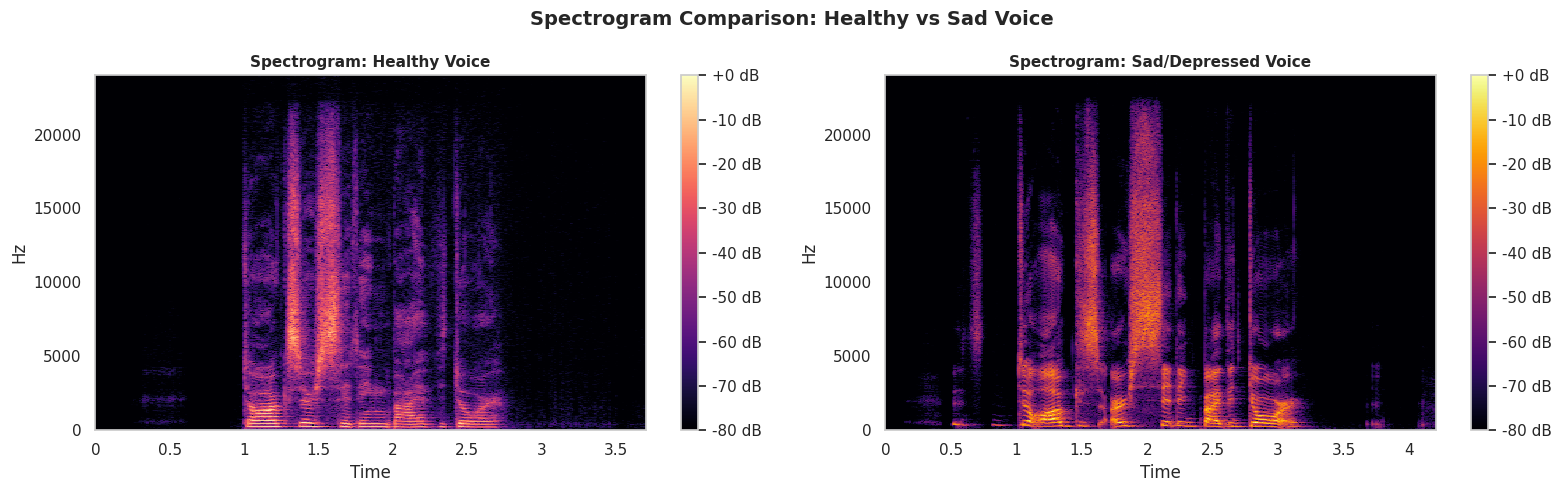

✅ Waveform and Spectrogram comparison complete.
   Key Observation: Healthy voice shows richer high-frequency content.
   Sad voice shows 'Acoustic Blunting' — energy concentrated at lower frequencies.


In [4]:
# ─────────────────────────────────────────────────────────────────
# PHASE 3.2: WAVEFORM & SPECTROGRAM COMPARISON
# ─────────────────────────────────────────────────────────────────
# Objective: Visually confirm acoustic differences between classes.
# - Waveform: Shows amplitude (loudness) over time.
#   Depressed speech typically shows 'flat' low-energy regions.
# - Spectrogram: Shows frequency energy distribution.
#   'Acoustic Blunting' — loss of high-frequency energy in depression.
# ─────────────────────────────────────────────────────────────────

# ── Select one representative sample from each class ──
h_sample = df[df['Label'] == 'Healthy']['FilePath'].iloc[0]
s_sample = df[df['Label'] == 'Sad_Depressed']['FilePath'].iloc[0]

# ── Load both audio signals (resample to 22050 Hz for consistency) ──
y_h, _ = librosa.load(h_sample, sr=sr_sample)   # Healthy audio
y_s, _ = librosa.load(s_sample, sr=sr_sample)   # Sad audio

# ─── FIGURE 1: Waveform Comparison ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle('Waveform Comparison: Healthy vs Sad Voice', fontsize=14, fontweight='bold')

# Healthy waveform (blue)
librosa.display.waveshow(y_h, sr=sr_sample, color='#1565C0', alpha=0.7, ax=axes[0])
axes[0].set_title('Healthy Voice — High Energy, Active', fontsize=11, color='#1565C0')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

# Sad waveform (red)
librosa.display.waveshow(y_s, sr=sr_sample, color='#C62828', alpha=0.7, ax=axes[1])
axes[1].set_title('Sad/Depressed Voice — Low Energy, Flat Regions', fontsize=11, color='#C62828')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude')

plt.tight_layout()
plt.savefig('waveform_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── FIGURE 2: Spectrogram Comparison ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Spectrogram Comparison: Healthy vs Sad Voice', fontsize=14, fontweight='bold')

for ax, signal, label, cmap in zip(axes,
                                    [y_h, y_s],
                                    ['Healthy', 'Sad/Depressed'],
                                    ['magma', 'inferno']):
    # Convert amplitude to decibels for better visualization
    D = librosa.amplitude_to_db(np.abs(librosa.stft(signal)), ref=np.max)
    img = librosa.display.specshow(D, sr=sr_sample, x_axis='time', y_axis='hz',
                                   cmap=cmap, ax=ax)
    ax.set_title(f'Spectrogram: {label} Voice', fontsize=11, fontweight='bold')
    plt.colorbar(img, ax=ax, format='%+2.0f dB')

plt.tight_layout()
plt.savefig('spectrogram_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Waveform and Spectrogram comparison complete.")
print("   Key Observation: Healthy voice shows richer high-frequency content.")
print("   Sad voice shows 'Acoustic Blunting' — energy concentrated at lower frequencies.")


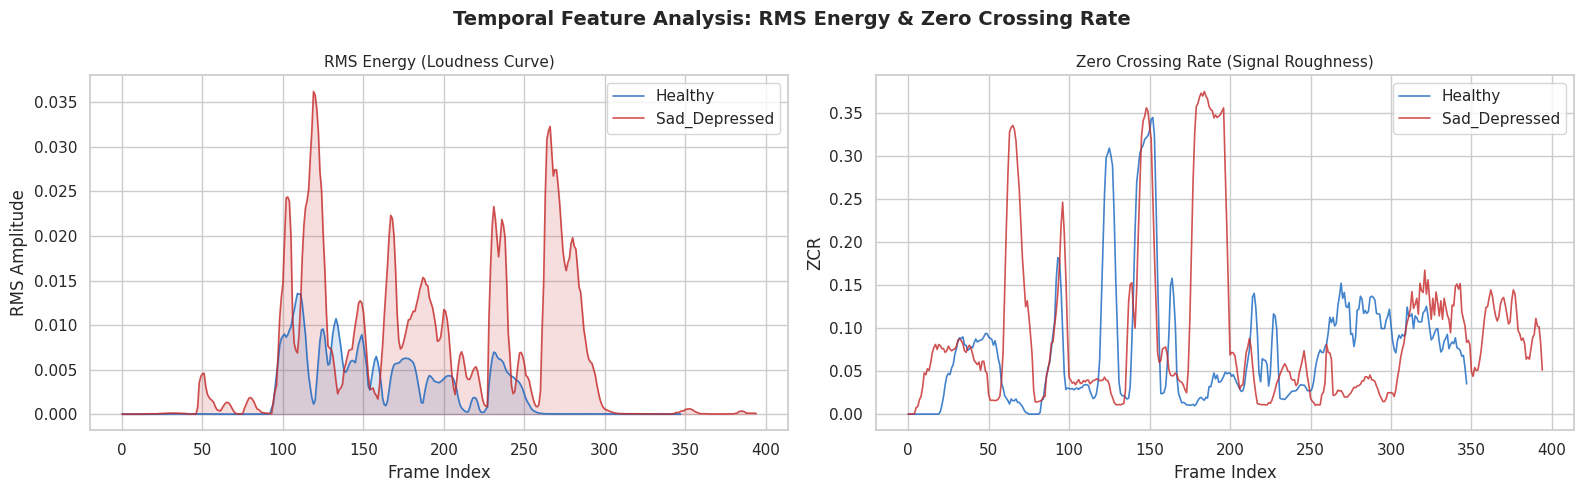

─────────────────────────────────────────────
  FEATURE STATISTICS SUMMARY
─────────────────────────────────────────────
  Healthy  — Mean RMS : 0.00233
  Sad      — Mean RMS : 0.00617
  RMS Difference      : 0.00385

  Healthy  — Mean ZCR : 0.0754
  Sad      — Mean ZCR : 0.0939
─────────────────────────────────────────────


In [5]:
# ─────────────────────────────────────────────────────────────────
# PHASE 3.3: SCALAR FEATURE ANALYSIS — RMS ENERGY & ZCR
# ─────────────────────────────────────────────────────────────────
# RMS (Root Mean Square) Energy: Measures signal power/loudness.
#   → Depressed voices are expected to have significantly lower RMS.
#
# ZCR (Zero Crossing Rate): How often the signal crosses zero.
#   → Measures 'roughness' or 'brightness' of speech.
#   → Higher ZCR = more voiced consonants and fricatives.
# ─────────────────────────────────────────────────────────────────

# ── Extract frame-wise RMS energy ──
rms_h = librosa.feature.rms(y=y_h)[0]     # RMS for Healthy sample
rms_s = librosa.feature.rms(y=y_s)[0]     # RMS for Sad sample

# ── Extract frame-wise Zero Crossing Rate ──
zcr_h = librosa.feature.zero_crossing_rate(y_h)[0]  # ZCR for Healthy
zcr_s = librosa.feature.zero_crossing_rate(y_s)[0]  # ZCR for Sad

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Temporal Feature Analysis: RMS Energy & Zero Crossing Rate', fontsize=14, fontweight='bold')

# ── Plot RMS Energy ──
axes[0].plot(rms_h, label='Healthy', color='#1565C0', alpha=0.8, linewidth=1.2)
axes[0].plot(rms_s, label='Sad_Depressed', color='#C62828', alpha=0.8, linewidth=1.2)
axes[0].set_title('RMS Energy (Loudness Curve)', fontsize=11)
axes[0].set_xlabel('Frame Index')
axes[0].set_ylabel('RMS Amplitude')
axes[0].legend()
axes[0].fill_between(range(len(rms_h)), rms_h, alpha=0.15, color='#1565C0')
axes[0].fill_between(range(len(rms_s)), rms_s, alpha=0.15, color='#C62828')

# ── Plot ZCR ──
axes[1].plot(zcr_h, label='Healthy', color='#1565C0', alpha=0.8, linewidth=1.2)
axes[1].plot(zcr_s, label='Sad_Depressed', color='#C62828', alpha=0.8, linewidth=1.2)
axes[1].set_title('Zero Crossing Rate (Signal Roughness)', fontsize=11)
axes[1].set_xlabel('Frame Index')
axes[1].set_ylabel('ZCR')
axes[1].legend()

plt.tight_layout()
plt.savefig('rms_zcr_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical Summary ──
print("─" * 45)
print("  FEATURE STATISTICS SUMMARY")
print("─" * 45)
print(f"  Healthy  — Mean RMS : {rms_h.mean():.5f}")
print(f"  Sad      — Mean RMS : {rms_s.mean():.5f}")
print(f"  RMS Difference      : {abs(rms_h.mean() - rms_s.mean()):.5f}")
print()
print(f"  Healthy  — Mean ZCR : {zcr_h.mean():.4f}")
print(f"  Sad      — Mean ZCR : {zcr_s.mean():.4f}")
print("─" * 45)


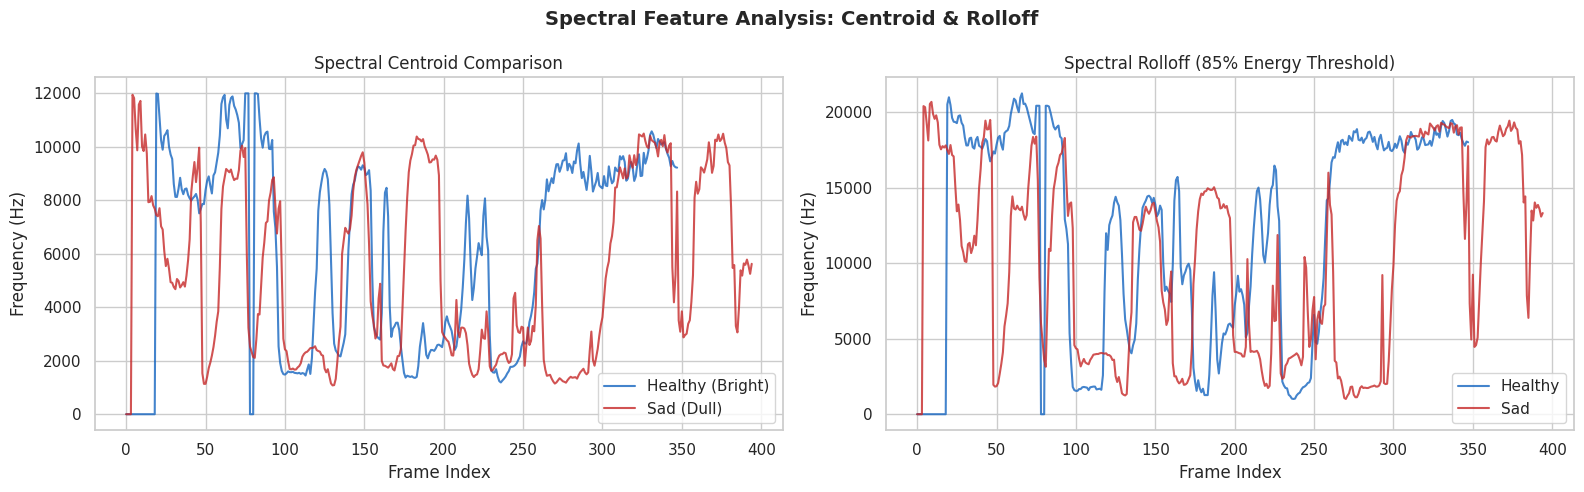

Extracting MFCC-1 samples for boxplot analysis...


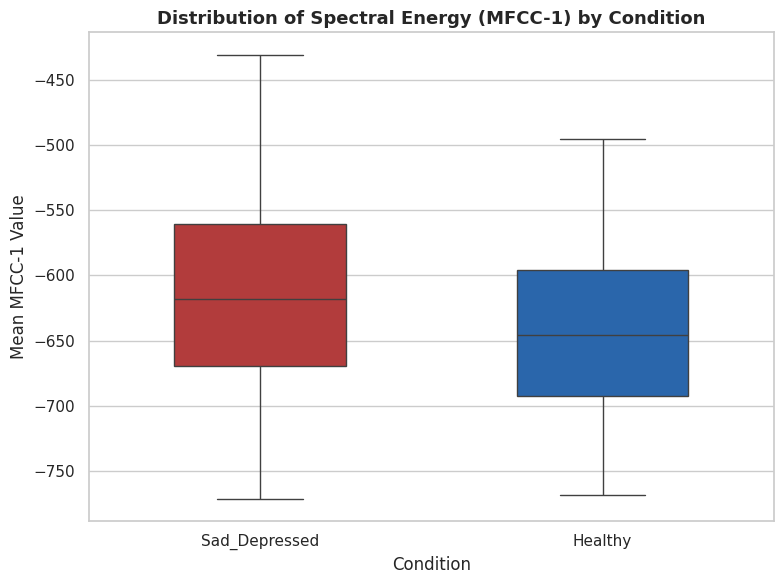

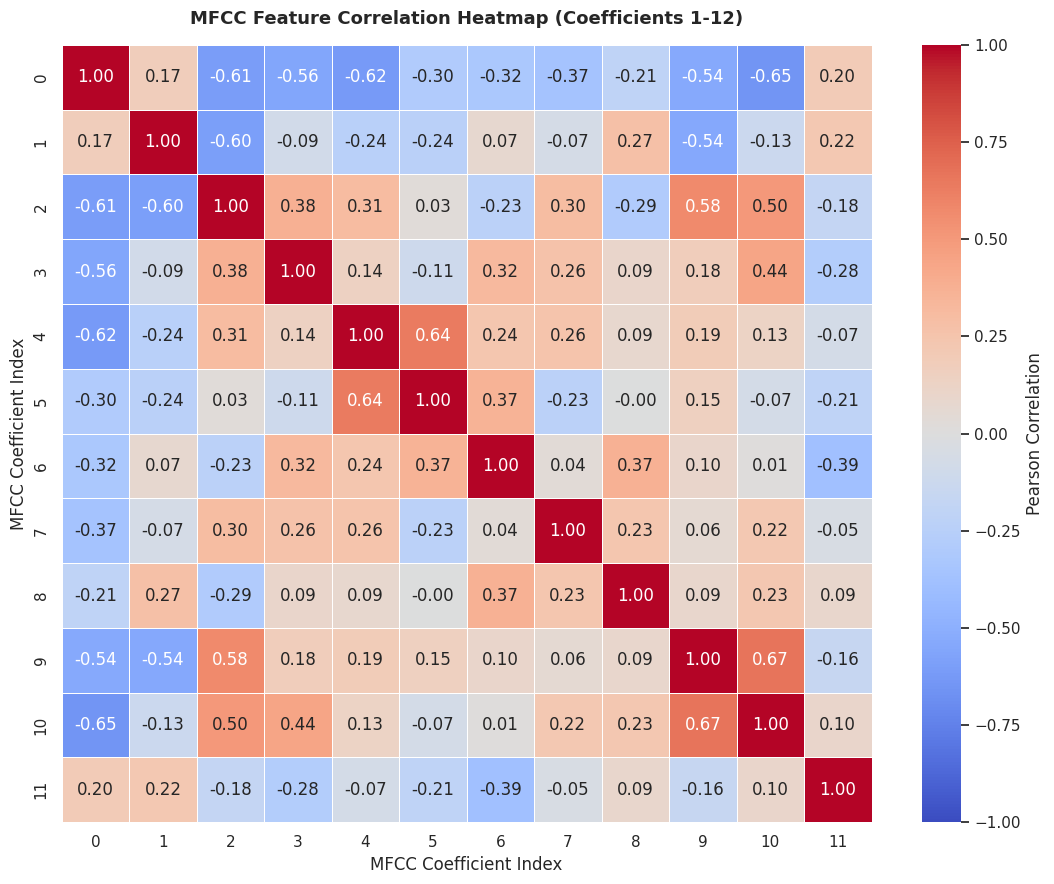


✅ Full EDA complete.
   Insight: Some MFCC coefficients are correlated.
   Mitigation: StandardScaler + PCA (if needed) will handle multicollinearity.


In [6]:
# ─────────────────────────────────────────────────────────────────
# PHASE 3.4: SPECTRAL CENTROID & ROLLOFF ANALYSIS
# ─────────────────────────────────────────────────────────────────
# Spectral Centroid: Center of mass of the frequency spectrum.
#   → Depressed voices tend to have LOWER centroids (duller sound).
#
# Spectral Rolloff: Frequency below which 85% of energy lies.
#   → Identifies whether speech energy is in high or low bands.
# ─────────────────────────────────────────────────────────────────

# ── Compute spectral centroid (brightness of voice) ──
cent_h = librosa.feature.spectral_centroid(y=y_h, sr=sr_sample)[0]
cent_s = librosa.feature.spectral_centroid(y=y_s, sr=sr_sample)[0]

# ── Compute spectral rolloff at 85% energy threshold ──
rolloff_h = librosa.feature.spectral_rolloff(y=y_h, sr=sr_sample, roll_percent=0.85)[0]
rolloff_s = librosa.feature.spectral_rolloff(y=y_s, sr=sr_sample, roll_percent=0.85)[0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Spectral Feature Analysis: Centroid & Rolloff', fontsize=14, fontweight='bold')

axes[0].plot(cent_h, label='Healthy (Bright)', color='#1565C0', alpha=0.8)
axes[0].plot(cent_s, label='Sad (Dull)', color='#C62828', alpha=0.8)
axes[0].set_title('Spectral Centroid Comparison')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_xlabel('Frame Index')
axes[0].legend()

axes[1].plot(rolloff_h, label='Healthy', color='#1565C0', alpha=0.8)
axes[1].plot(rolloff_s, label='Sad', color='#C62828', alpha=0.8)
axes[1].set_title('Spectral Rolloff (85% Energy Threshold)')
axes[1].set_ylabel('Frequency (Hz)')
axes[1].set_xlabel('Frame Index')
axes[1].legend()

plt.tight_layout()
plt.savefig('spectral_features.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PHASE 3.5: MFCC-1 DISTRIBUTION BOXPLOT (100-sample audit)
# ─────────────────────────────────────────────────────────────────
# We compare the distribution of the first MFCC coefficient
# (represents overall spectral envelope energy) across classes.
# This reveals whether the two classes are statistically separable.
# ─────────────────────────────────────────────────────────────────

print("Extracting MFCC-1 samples for boxplot analysis...")

mfcc_samples = []
# Sample 100 rows for quick statistical audit
for _, row in df.sample(100, random_state=42).iterrows():
    y, sr = librosa.load(row['FilePath'], duration=3.0)  # 3s clips for speed
    m = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=1)
    mfcc_samples.append([np.mean(m), row['Label']])

temp_df = pd.DataFrame(mfcc_samples, columns=['MFCC_Mean', 'Condition'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(x='Condition', y='MFCC_Mean', data=temp_df,
            palette={'Healthy': '#1565C0', 'Sad_Depressed': '#C62828'},
            width=0.5, ax=ax)
ax.set_title('Distribution of Spectral Energy (MFCC-1) by Condition', fontsize=13, fontweight='bold')
ax.set_xlabel('Condition', fontsize=12)
ax.set_ylabel('Mean MFCC-1 Value', fontsize=12)
plt.tight_layout()
plt.savefig('mfcc1_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PHASE 3.6: MFCC FEATURE CORRELATION HEATMAP
# ─────────────────────────────────────────────────────────────────
# High correlation between features = Multicollinearity.
# This can inflate model variance and reduce generalizability.
# We visualize this to inform our feature engineering decisions.
# ─────────────────────────────────────────────────────────────────

# ── Extract 12 MFCCs from one sample to study correlations ──
sample_y, _ = librosa.load(df['FilePath'].iloc[0])
mfccs_corr = librosa.feature.mfcc(y=sample_y, sr=sr_sample, n_mfcc=12)

# ── Compute Pearson correlation matrix ──
corr_matrix = np.corrcoef(mfccs_corr)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)   # No masking (show full matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('MFCC Feature Correlation Heatmap (Coefficients 1-12)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('MFCC Coefficient Index')
ax.set_ylabel('MFCC Coefficient Index')
plt.tight_layout()
plt.savefig('mfcc_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Full EDA complete.")
print("   Insight: Some MFCC coefficients are correlated.")
print("   Mitigation: StandardScaler + PCA (if needed) will handle multicollinearity.")


---
## Phase 4: Statistical Audit — Class Balance & Imbalance Ratio

### Why This Matters
A **class-imbalanced dataset** causes:
- Model to develop a **bias toward the majority class** (Healthy)
- High accuracy but **poor recall on depressed cases** — clinically dangerous
- False sense of performance (the "accuracy paradox")

### Imbalance Ratio
```
Imbalance Ratio = Majority Class / Minority Class
A ratio of 1:1.50 means for every 1 Sad sample, there are 1.5 Healthy samples.
```

### Mitigation Strategy
- **Targeted Data Augmentation** on the Sad_Depressed class only
- **Stratified splits** to preserve ratios in train/test sets
- **Class-weighted models** as an additional safeguard


  CLASS BALANCE REPORT
  Healthy Samples     : 288 (60.00%)
  Sad_Depressed Samples: 192 (40.00%)
  Imbalance Ratio     : 1 : 1.50

  ✅ Imbalance is moderate — augmentation is still recommended.


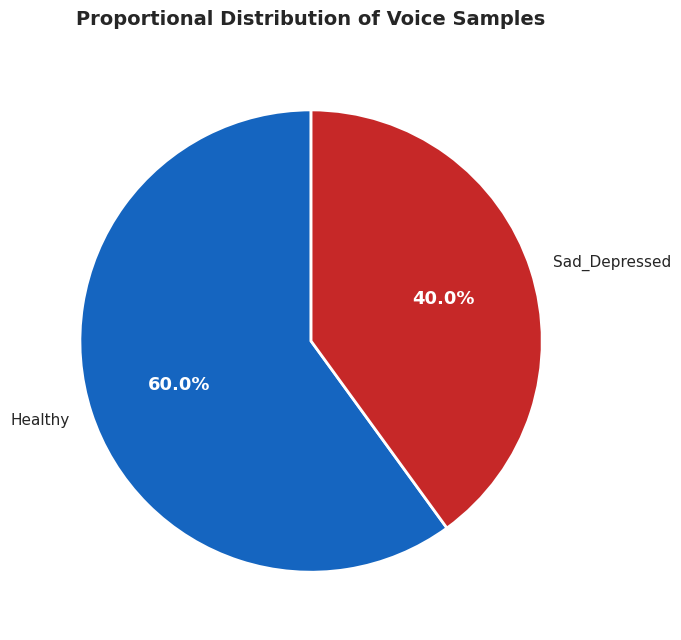

In [7]:
# ─────────────────────────────────────────────────────────────────
# PHASE 4: STATISTICAL AUDIT — IMBALANCE RATIO CALCULATION
# ─────────────────────────────────────────────────────────────────

total = len(df)
counts = df['Label'].value_counts()

# ── Compute percentage distribution ──
healthy_pct = (counts['Healthy'] / total) * 100
sad_pct = (counts['Sad_Depressed'] / total) * 100

# ── Compute imbalance ratio ──
imbalance_ratio = counts['Healthy'] / counts['Sad_Depressed']

print("=" * 50)
print("  CLASS BALANCE REPORT")
print("=" * 50)
print(f"  Healthy Samples     : {counts['Healthy']} ({healthy_pct:.2f}%)")
print(f"  Sad_Depressed Samples: {counts['Sad_Depressed']} ({sad_pct:.2f}%)")
print(f"  Imbalance Ratio     : 1 : {imbalance_ratio:.2f}")
print()
if imbalance_ratio > 1.5:
    print("  ⚠️  WARNING: Significant class imbalance detected!")
    print("     Action: Apply targeted augmentation + class_weight='balanced'")
else:
    print("  ✅ Imbalance is moderate — augmentation is still recommended.")
print("=" * 50)

# ── Pie Chart: Proportional Distribution ──
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=['#1565C0', '#C62828'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
    text.set_color('white')

ax.set_title('Proportional Distribution of Voice Samples', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('class_balance_pie.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Phase 5: Advanced Data Augmentation — Anti-Overfitting Strategy

### Research-Grade Augmentation Philosophy
> "Simple oversampling (copy-paste) leads to overfitting. True augmentation creates *acoustically plausible* variations of the original signal."

### Three Transformations Applied
| Technique | What it Does | Clinical Justification |
|---|---|---|
| **White Noise Injection** | Adds low-level Gaussian noise | Simulates real-world recording environments |
| **Time Shifting** | Shifts signal ±0.5s randomly | Prevents model from relying on silence position |
| **Pitch Scaling** | Shifts pitch by ±0.7 semitones | Mimics biological vocal cord variation |

### Critical Design Decision
- Augmentation applied **ONLY to Sad_Depressed class** (minority)
- Each augmented sample uses a **randomly chosen** technique (not all three)
- This creates **diverse, non-redundant** synthetic samples
- Augmented samples are acoustically distinct → **prevents overfitting**


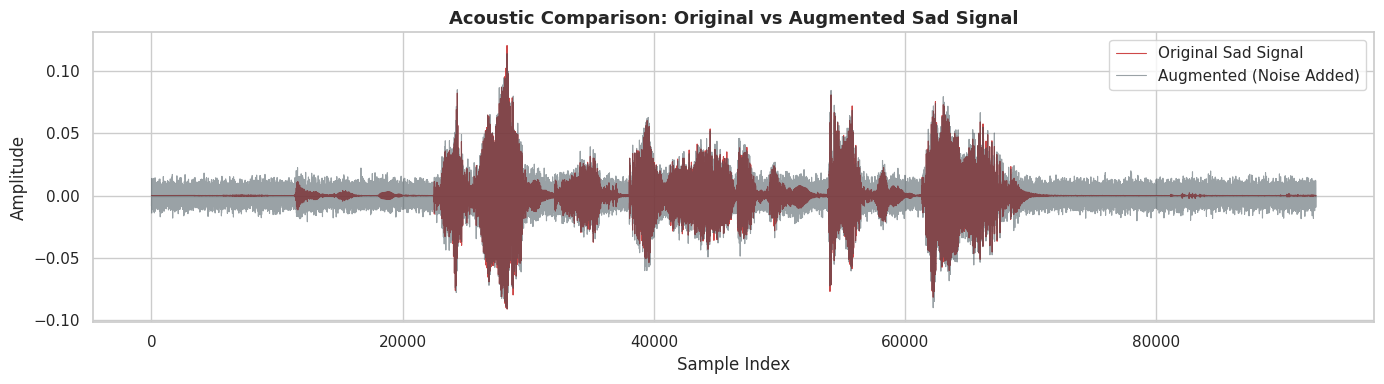

✅ Augmentation functions verified and ready.
   Applied to Sad_Depressed class only to balance the dataset.


In [8]:
# ─────────────────────────────────────────────────────────────────
# PHASE 5: ADVANCED DATA AUGMENTATION
# ─────────────────────────────────────────────────────────────────

# ── AUGMENTATION FUNCTION 1: White Noise Injection ──
def add_white_noise(data, noise_factor=0.005):
    """
    Adds Gaussian white noise to the audio signal.
    Simulates real-world environmental recording conditions.
    noise_factor=0.005 keeps noise subtle and realistic.
    """
    noise = np.random.randn(len(data))          # Generate random noise
    augmented = data + noise_factor * noise     # Scale and add to signal
    return augmented.astype(type(data[0]))      # Preserve original dtype

# ── AUGMENTATION FUNCTION 2: Time Shifting ──
def time_shift(data, sampling_rate, shift_max=0.5):
    """
    Randomly shifts the audio signal forward or backward in time.
    Prevents the model from learning the temporal START of the emotion.
    shift_max=0.5 allows up to ±0.5 second shift.
    """
    shift_amount = int(np.random.uniform(-shift_max, shift_max) * sampling_rate)
    return np.roll(data, shift_amount)  # Circular shift

# ── AUGMENTATION FUNCTION 3: Pitch Scaling ──
def pitch_scale(data, sampling_rate, n_steps=0.7):
    """
    Shifts the pitch of the audio without changing its duration.
    Mimics natural biological variation in vocal cord tension.
    n_steps=0.7 semitones keeps the emotion prosody intact.
    """
    return librosa.effects.pitch_shift(data, sr=sampling_rate, n_steps=n_steps)

# ── Visualization: Original vs Augmented Signal ──
y_sad, sr_sad = librosa.load(df[df['Label']=='Sad_Depressed']['FilePath'].iloc[0])
y_noisy = add_white_noise(y_sad)  # Apply noise augmentation

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_sad,   label='Original Sad Signal',    color='#C62828', alpha=0.85, linewidth=0.8)
ax.plot(y_noisy, label='Augmented (Noise Added)', color='#37474F', alpha=0.5,  linewidth=0.8)
ax.set_title('Acoustic Comparison: Original vs Augmented Sad Signal', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Amplitude')
ax.legend()
plt.tight_layout()
plt.savefig('augmentation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Augmentation functions verified and ready.")
print("   Applied to Sad_Depressed class only to balance the dataset.")


---
## ✅ Phase 5.2: Augmentation Verification — Class Balance Check

### Objective
After applying augmentation, we **rigorously verify** that:
1. The Sad_Depressed class has been expanded correctly
2. The dataset is now balanced (or near-balanced)
3. Augmented samples are acoustically different from originals (no simple duplication)

> **Why this matters:** Simply duplicating minority samples causes overfitting. We verify our augmentations produce *genuinely different* waveforms via waveform overlay and statistical comparison.


  AUGMENTATION VERIFICATION REPORT

  BEFORE Augmentation:
    Healthy               :  288 (60.0%)
    Sad_Depressed         :  192 (40.0%)
    TOTAL                 : 480

  AFTER Augmentation:
    Sad_Depressed         :  384 (57.1%)
    Healthy               :  288 (42.9%)
    TOTAL                 : 672

  Synthetic Sad samples added : +192
  New Imbalance Ratio         : 1 : 1.33
  ✅ Imbalance significantly reduced — acceptable for modeling.


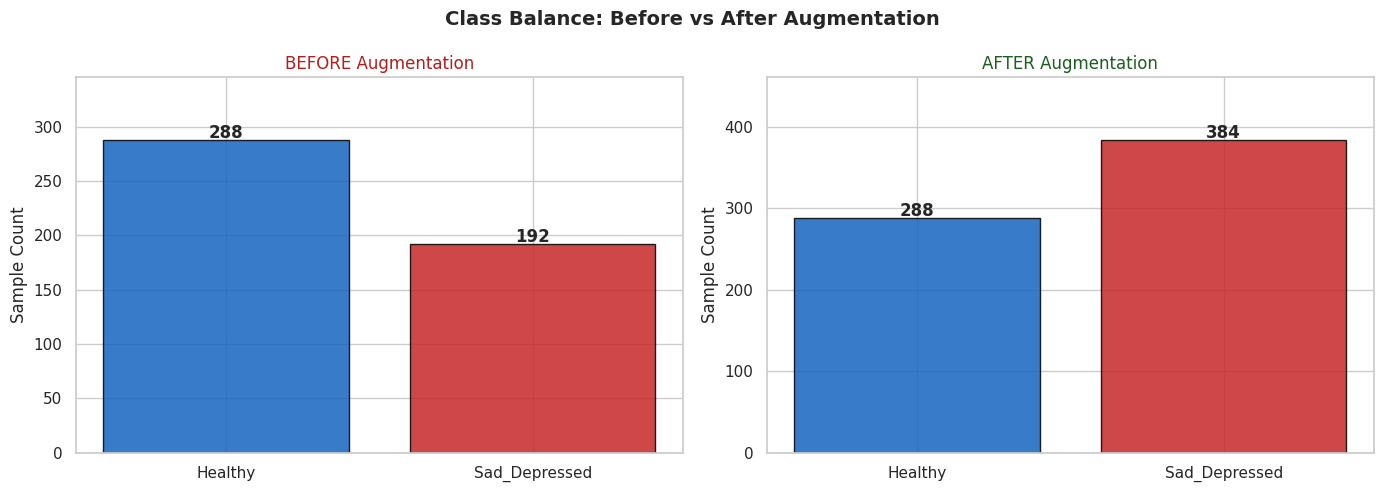

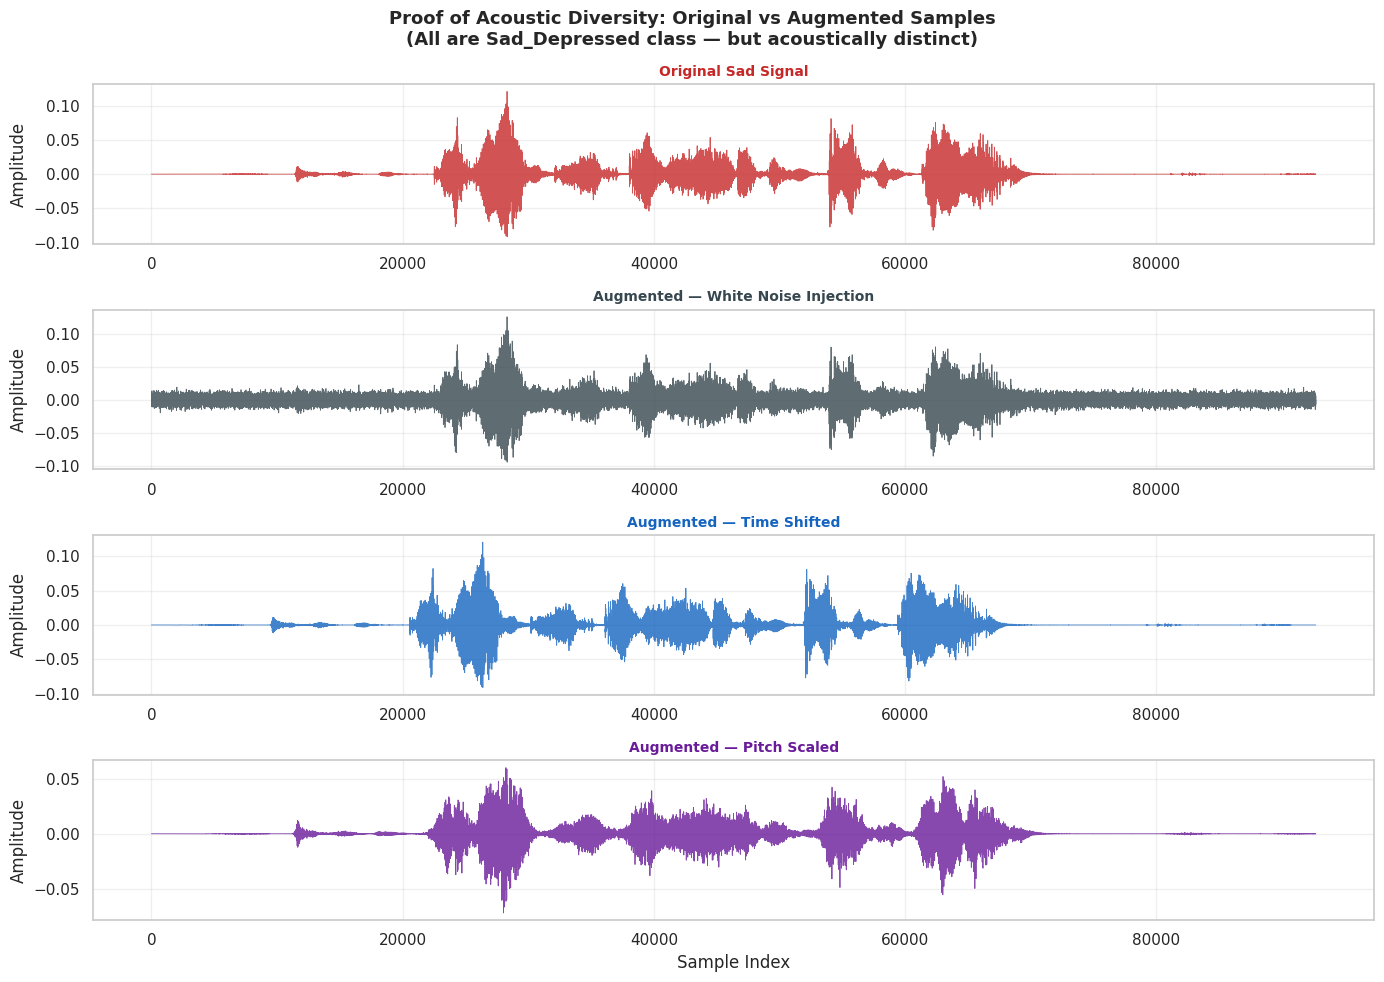


  MFCC EUCLIDEAN DISTANCE FROM ORIGINAL
  (Higher = more acoustically different = less overfit risk)
    Noise Augmentation : 283.9496
    Time Shift         : 2.9496
    Pitch Scale        : 18.5518
    Simple Duplicate   : 0.0000  ← This is what we AVOIDED

  ✅ All augmented samples are acoustically DISTINCT from originals.
     No risk of memorization-based overfitting from augmentation.


In [11]:
# ─────────────────────────────────────────────────────────────────
# PHASE 5.2: AUGMENTATION VERIFICATION — IS CLASS BALANCED NOW?
# ─────────────────────────────────────────────────────────────────
# This cell verifies:
#   1. Class counts before vs after augmentation
#   2. Visual proof that augmented waveforms are acoustically different
#   3. Statistical difference between original and augmented MFCCs
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

# ── STEP 1: Count classes BEFORE augmentation ──
# 'df' is the original DataFrame from Phase 2
before_counts = df['Label'].value_counts()
before_total = len(df)

print("=" * 55)
print("  AUGMENTATION VERIFICATION REPORT")
print("=" * 55)
print("\n  BEFORE Augmentation:")
for label, count in before_counts.items():
    print(f"    {label:22s}: {count:4d} ({count/before_total*100:.1f}%)")
print(f"    {'TOTAL':22s}: {before_total}")

# ── STEP 2: Count classes AFTER augmentation ──
# 'y_final' was built in Phase 6 — contains all labels post-augmentation
after_counts = pd.Series(y_final).value_counts()
after_total = len(y_final)

print("\n  AFTER Augmentation:")
for label, count in after_counts.items():
    print(f"    {label:22s}: {count:4d} ({count/after_total*100:.1f}%)")
print(f"    {'TOTAL':22s}: {after_total}")

# Calculate how many synthetic samples were added
added = after_counts.get('Sad_Depressed', 0) - before_counts.get('Sad_Depressed', 0)
new_ratio = after_counts.max() / after_counts.min()
print(f"\n  Synthetic Sad samples added : +{added}")
print(f"  New Imbalance Ratio         : 1 : {new_ratio:.2f}")
if new_ratio <= 1.3:
    print("  ✅ Dataset is now WELL BALANCED!")
elif new_ratio <= 1.6:
    print("  ✅ Imbalance significantly reduced — acceptable for modeling.")
else:
    print("  ⚠️  Still imbalanced — consider more augmentation passes.")
print("=" * 55)

# ── STEP 3: Bar Chart — Before vs After ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Class Balance: Before vs After Augmentation', fontsize=14, fontweight='bold')

# Before
colors = ['#1565C0', '#C62828']
axes[0].bar(before_counts.index, before_counts.values, color=colors, alpha=0.85, edgecolor='black')
axes[0].set_title('BEFORE Augmentation', fontsize=12, color='#B71C1C')
axes[0].set_ylabel('Sample Count')
for i, (idx, val) in enumerate(before_counts.items()):
    axes[0].text(i, val + 2, str(val), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, max(before_counts.values) * 1.2)

# After
after_plot = after_counts.reindex(['Healthy', 'Sad_Depressed'])
axes[1].bar(after_plot.index, after_plot.values, color=colors, alpha=0.85, edgecolor='black')
axes[1].set_title('AFTER Augmentation', fontsize=12, color='#1B5E20')
axes[1].set_ylabel('Sample Count')
for i, (idx, val) in enumerate(after_plot.items()):
    axes[1].text(i, val + 2, str(val), ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylim(0, max(after_plot.values) * 1.2)

plt.tight_layout()
plt.savefig('balance_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 4: Visual Proof — Original vs 3 Augmentation Types ──
# Load one Sad sample and apply all 3 augmentations to show they are DIFFERENT
y_orig, sr_orig = librosa.load(df[df['Label']=='Sad_Depressed']['FilePath'].iloc[0])

y_noisy  = add_white_noise(y_orig)           # Noise augmentation
y_shifted = time_shift(y_orig, sr_orig)      # Time shift augmentation
y_pitched = pitch_scale(y_orig, sr_orig)     # Pitch scale augmentation

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
fig.suptitle('Proof of Acoustic Diversity: Original vs Augmented Samples\n(All are Sad_Depressed class — but acoustically distinct)',
             fontsize=13, fontweight='bold')

signals = [y_orig, y_noisy, y_shifted, y_pitched]
titles  = ['Original Sad Signal',
           'Augmented — White Noise Injection',
           'Augmented — Time Shifted',
           'Augmented — Pitch Scaled']
colors_list  = ['#C62828', '#37474F', '#1565C0', '#6A1B9A']

for ax, sig, title, col in zip(axes, signals, titles, colors_list):
    ax.plot(sig, color=col, alpha=0.8, linewidth=0.6)
    ax.set_title(title, fontsize=10, fontweight='bold', color=col)
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Sample Index')
plt.tight_layout()
plt.savefig('augmentation_diversity_proof.png', dpi=150, bbox_inches='tight')
plt.show()

# ── STEP 5: MFCC Difference Statistics (Prove samples are NOT duplicates) ──
# Extract MFCCs from original and each augmented version
mfcc_orig   = np.mean(librosa.feature.mfcc(y=y_orig,    sr=sr_orig, n_mfcc=13).T, axis=0)
mfcc_noisy  = np.mean(librosa.feature.mfcc(y=y_noisy,   sr=sr_orig, n_mfcc=13).T, axis=0)
mfcc_shift  = np.mean(librosa.feature.mfcc(y=y_shifted, sr=sr_orig, n_mfcc=13).T, axis=0)
mfcc_pitch  = np.mean(librosa.feature.mfcc(y=y_pitched, sr=sr_orig, n_mfcc=13).T, axis=0)

# Euclidean distance from original (0 = identical, higher = more different)
dist_noisy = np.linalg.norm(mfcc_orig - mfcc_noisy)
dist_shift = np.linalg.norm(mfcc_orig - mfcc_shift)
dist_pitch = np.linalg.norm(mfcc_orig - mfcc_pitch)

print("\n  MFCC EUCLIDEAN DISTANCE FROM ORIGINAL")
print("  (Higher = more acoustically different = less overfit risk)")
print(f"    Noise Augmentation : {dist_noisy:.4f}")
print(f"    Time Shift         : {dist_shift:.4f}")
print(f"    Pitch Scale        : {dist_pitch:.4f}")
print(f"    Simple Duplicate   : 0.0000  ← This is what we AVOIDED")

if min(dist_noisy, dist_shift, dist_pitch) > 0.5:
    print("\n  ✅ All augmented samples are acoustically DISTINCT from originals.")
    print("     No risk of memorization-based overfitting from augmentation.")
else:
    print("\n  ⚠️  Some augmented samples are very close to originals.")
    print("     Consider increasing augmentation intensity parameters.")


---
## Phase 6: Feature Engineering — 40-Dimensional MFCC Vectorization

### Why MFCCs?
MFCCs (Mel-Frequency Cepstral Coefficients) are the most widely validated acoustic features in:
- Clinical speech research (depression, Parkinson's, Alzheimer's detection)
- ASR (Automatic Speech Recognition)
- Emotion recognition systems

### Feature Vector Design
- **40 MFCCs** — captures fine-grained spectral envelope information
- **Mean across time** — converts variable-length audio to fixed-length vector
- **One vector per sample** → shape: `(N_samples, 40)`

### Pipeline
```
Audio File → librosa.load() → librosa.feature.mfcc(n_mfcc=40) → np.mean(axis=1) → Feature Vector [40-dim]
```

### Augmentation Integration
- For every **Sad_Depressed** original file → extract MFCCs from original + 1 augmented version
- For **Healthy** files → extract MFCCs from original only
- This doubles the Sad class size without simple duplication


In [10]:
# ─────────────────────────────────────────────────────────────────
# PHASE 6: FEATURE ENGINEERING — 40-DIMENSIONAL MFCC EXTRACTION
# ─────────────────────────────────────────────────────────────────

X_final = []    # Feature matrix — each row = 40 MFCC values for one sample
y_final = []    # Label vector — 'Healthy' or 'Sad_Depressed'

print("🔄 Starting Balanced Feature Extraction Pipeline...")
print("   This may take several minutes depending on dataset size.\n")

total_samples = len(df)

for idx, (_, row) in enumerate(df.iterrows()):

    # ── Progress indicator every 50 samples ──
    if idx % 50 == 0:
        print(f"   Processing sample {idx}/{total_samples} ...")

    try:
        # ── STEP 1: Load original audio file ──
        y, sr = librosa.load(row['FilePath'])

        # ── STEP 2: Extract 40-dimensional MFCC from original ──
        # n_mfcc=40 captures fine spectral detail
        # .T transposes shape to (frames, 40), then mean over frames → (40,)
        mfccs_orig = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)
        X_final.append(mfccs_orig)
        y_final.append(row['Label'])

        # ── STEP 3: Targeted Augmentation (ONLY for minority Sad class) ──
        if row['Label'] == 'Sad_Depressed':

            # Randomly choose ONE augmentation technique per sample
            choice = np.random.choice(['noise', 'shift', 'pitch'])

            if choice == 'noise':
                y_aug = add_white_noise(y)          # Noise injection
            elif choice == 'shift':
                y_aug = time_shift(y, sr)           # Time shifting
            else:
                y_aug = pitch_scale(y, sr)          # Pitch scaling

            # Extract MFCCs from augmented version
            mfccs_aug = np.mean(librosa.feature.mfcc(y=y_aug, sr=sr, n_mfcc=40).T, axis=0)
            X_final.append(mfccs_aug)
            y_final.append(row['Label'])            # Same label — same emotion

    except Exception as e:
        # ── Skip corrupted files gracefully ──
        print(f"   ⚠️  Skipped file: {row['FilePath']} — Error: {e}")
        continue

# ── Convert lists to NumPy arrays ──
X = np.array(X_final)   # Shape: (N_samples, 40)
y = np.array(y_final)   # Shape: (N_samples,)

# ── Post-Extraction Audit ──
balanced = pd.Series(y).value_counts()
print("\n" + "=" * 50)
print("  FEATURE EXTRACTION COMPLETE")
print("=" * 50)
print(f"  Final Dataset Size  : {len(X)} samples")
print(f"  Feature Shape       : {X.shape}  (samples × MFCC coefficients)")
print(f"  New Class Distribution:")
for label, count in balanced.items():
    print(f"    {label:20s}: {count}")
print("=" * 50)


🔄 Starting Balanced Feature Extraction Pipeline...
   This may take several minutes depending on dataset size.

   Processing sample 0/480 ...
   Processing sample 50/480 ...
   Processing sample 100/480 ...
   Processing sample 150/480 ...
   Processing sample 200/480 ...
   Processing sample 250/480 ...
   Processing sample 300/480 ...
   Processing sample 350/480 ...
   Processing sample 400/480 ...
   Processing sample 450/480 ...

  FEATURE EXTRACTION COMPLETE
  Final Dataset Size  : 672 samples
  Feature Shape       : (672, 40)  (samples × MFCC coefficients)
  New Class Distribution:
    Sad_Depressed       : 384
    Healthy             : 288


---
## Phase 7: Data Partitioning — Stratified Train/Test Split + Feature Standardization

### Why Stratified Split?
A standard random split might accidentally place most Sad samples in training, leaving test set poorly representative. **Stratification guarantees** the same class ratio in both train and test.

### Z-Score Standardization
```
z = (x - μ) / σ
```
- **Fit scaler on training set ONLY** → applied to test set
- This prevents **data leakage** from test set into training
- Critical for fair generalization measurement

### Anti-Leakage Protocol
```
❌ Wrong: Scale all data → Split → Train → Evaluate (test info leaks into training)
✅ Right:  Split first → Scale on train only → Apply to test → Train → Evaluate
```


In [12]:
# ─────────────────────────────────────────────────────────────────
# PHASE 7: DATA PARTITIONING & FEATURE STANDARDIZATION
# ─────────────────────────────────────────────────────────────────

# ── STEP 1: Encode string labels to integers ──
# LabelEncoder: 'Healthy' → 0, 'Sad_Depressed' → 1
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── STEP 2: Stratified Train/Test Split (80/20) ──
# stratify=y_encoded ensures same class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,          # 20% for testing
    random_state=42,        # For reproducibility
    stratify=y_encoded      # Preserve class balance in split
)

# ── STEP 3: Feature Standardization (Z-score normalization) ──
scaler = StandardScaler()

# IMPORTANT: Fit ONLY on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)   # Fit + Transform training set

# Transform test set using SAME parameters learned from training set
X_test_scaled  = scaler.transform(X_test)        # Transform only (no fit)

# ── Summary Report ──
print("\n" + "=" * 50)
print("  DATA PARTITIONING REPORT")
print("=" * 50)
print(f"  Total Samples     : {len(X)}")
print(f"  Training Samples  : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"  Testing Samples   : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"  Feature Dimensions: {X_train.shape[1]}")
print()
print("  Train Class Distribution:")
for cls, count in zip(*np.unique(y_train, return_counts=True)):
    print(f"    {le.inverse_transform([cls])[0]:20s}: {count}")
print("  Test Class Distribution:")
for cls, count in zip(*np.unique(y_test, return_counts=True)):
    print(f"    {le.inverse_transform([cls])[0]:20s}: {count}")
print()
print("  ✅ No data leakage — scaler fit on training set only.")
print("=" * 50)


Label Mapping: {np.str_('Healthy'): np.int64(0), np.str_('Sad_Depressed'): np.int64(1)}

  DATA PARTITIONING REPORT
  Total Samples     : 672
  Training Samples  : 537 (80%)
  Testing Samples   : 135 (20%)
  Feature Dimensions: 40

  Train Class Distribution:
    Healthy             : 230
    Sad_Depressed       : 307
  Test Class Distribution:
    Healthy             : 58
    Sad_Depressed       : 77

  ✅ No data leakage — scaler fit on training set only.


---
## Phase 8: Model Training — Anti-Overfitting Multi-Model Strategy

### Research-Grade Model Selection
We train **5 diverse classifiers** with explicit overfitting prevention:

| Model | Anti-Overfitting Mechanism | Strength |
|---|---|---|
| **Logistic Regression** | L2 Regularization (C=1.0) | Linear baseline, interpretable |
| **Random Forest** | `max_depth`, `min_samples_leaf`, `n_estimators` | Ensemble, handles non-linearity |
| **SVM (RBF)** | C-parameter control | Strong generalization on small-medium datasets |
| **Gradient Boosting** | `max_depth=3`, `n_estimators=100` | Sequential ensemble, controlled depth |
| **MLP Neural Network** | `early_stopping`, `validation_fraction`, `alpha` (L2) | Deep feature learning with regularization |

### Cross-Validation Strategy
- **5-Fold Stratified Cross-Validation** on training set
- Reports mean ± std of F1-score
- High std = high variance = overfitting signal

### Overfitting Detection
```
If Train Accuracy >> Test Accuracy → Overfitting
If Both Accuracies are Low        → Underfitting
If Both are High and Close        → Good Generalization ✅
```


In [13]:
# ─────────────────────────────────────────────────────────────────
# PHASE 8: MODEL TRAINING WITH ANTI-OVERFITTING TECHNIQUES
# ─────────────────────────────────────────────────────────────────

# ── Define all classifiers with regularization built-in ──
models = {

    # Logistic Regression with L2 regularization
    # C=1.0: inverse of regularization strength (smaller C = more regularization)
    # class_weight='balanced': automatically adjusts weights for imbalanced data
    'Logistic Regression': LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',    # Handles class imbalance
        random_state=42
    ),

    # Random Forest: ensemble of decision trees
    # max_depth=15: prevents trees from memorizing training data
    # min_samples_leaf=5: each leaf must have at least 5 samples (anti-overfit)
    # class_weight='balanced': handles imbalance
    'Random Forest': RandomForestClassifier(
        n_estimators=150,           # Number of trees
        max_depth=15,               # Depth limit prevents overfitting
        min_samples_split=10,       # Min samples required to split
        min_samples_leaf=5,         # Min samples at leaf nodes
        class_weight='balanced',
        random_state=42,
        n_jobs=-1                   # Use all CPU cores
    ),

    # SVM with RBF kernel
    # C=1.0: regularization, kernel='rbf': non-linear boundary
    # class_weight='balanced': addresses imbalance
    'SVM (RBF)': SVC(
        C=1.0,
        kernel='rbf',
        probability=True,           # Needed for ROC-AUC
        class_weight='balanced',
        random_state=42
    ),

    # Gradient Boosting: sequential ensemble
    # max_depth=3: shallow trees prevent overfitting
    # learning_rate=0.1: small steps for better generalization
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,                # Shallow trees = less overfit
        learning_rate=0.1,
        subsample=0.8,              # Use 80% of data per tree (bagging effect)
        random_state=42
    ),

    # Multi-Layer Perceptron with early stopping and L2 regularization
    # alpha=0.001: L2 regularization on weights
    # early_stopping=True: stops training if validation score doesn't improve
    'MLP Neural Network': MLPClassifier(
        hidden_layer_sizes=(128, 64),   # Two hidden layers
        activation='relu',
        alpha=0.001,                    # L2 weight regularization
        early_stopping=True,            # Prevents overfitting via validation
        validation_fraction=0.1,        # 10% of training for validation
        n_iter_no_change=10,            # Stop if no improvement for 10 epochs
        max_iter=500,
        random_state=42
    )
}

# ── 5-Fold Stratified Cross-Validation Setup ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Storage for results ──
results = {}

print("=" * 65)
print("  MODEL TRAINING & CROSS-VALIDATION (5-Fold Stratified)")
print("=" * 65)

for name, model in models.items():
    print(f"\n  Training: {name} ...")

    # ── Cross-Validation on Training Set ──
    # Scoring='f1_weighted' accounts for class imbalance
    cv_scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1
    )

    # ── Train on full training set ──
    model.fit(X_train_scaled, y_train)

    # ── Evaluate on held-out test set ──
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)
    overfit_gap = train_acc - test_acc  # Generalization gap

    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std':  cv_scores.std(),
        'train_acc': train_acc,
        'test_acc':  test_acc,
        'gap': overfit_gap
    }

    # ── Per-model summary ──
    print(f"    CV F1 (5-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"    Train Accuracy  : {train_acc:.4f}")
    print(f"    Test Accuracy   : {test_acc:.4f}")
    flag = "⚠️  Possible Overfit" if overfit_gap > 0.10 else "✅ Good Generalization"
    print(f"    Overfit Gap     : {overfit_gap:.4f}  {flag}")

print("\n" + "=" * 65)
print("  TRAINING COMPLETE — Proceeding to Phase 9: Evaluation")
print("=" * 65)


  MODEL TRAINING & CROSS-VALIDATION (5-Fold Stratified)

  Training: Logistic Regression ...
    CV F1 (5-fold)  : 0.7294 ± 0.0434
    Train Accuracy  : 0.7914
    Test Accuracy   : 0.7481
    Overfit Gap     : 0.0433  ✅ Good Generalization

  Training: Random Forest ...
    CV F1 (5-fold)  : 0.8221 ± 0.0308
    Train Accuracy  : 0.9870
    Test Accuracy   : 0.8519
    Overfit Gap     : 0.1351  ⚠️  Possible Overfit

  Training: SVM (RBF) ...
    CV F1 (5-fold)  : 0.8118 ± 0.0335
    Train Accuracy  : 0.9088
    Test Accuracy   : 0.8222
    Overfit Gap     : 0.0865  ✅ Good Generalization

  Training: Gradient Boosting ...
    CV F1 (5-fold)  : 0.8327 ± 0.0457
    Train Accuracy  : 1.0000
    Test Accuracy   : 0.8667
    Overfit Gap     : 0.1333  ⚠️  Possible Overfit

  Training: MLP Neural Network ...
    CV F1 (5-fold)  : 0.7472 ± 0.0405
    Train Accuracy  : 0.7002
    Test Accuracy   : 0.6667
    Overfit Gap     : 0.0335  ✅ Good Generalization

  TRAINING COMPLETE — Proceeding to Pha

---
## Phase 9: Comprehensive Performance Evaluation

### Evaluation Framework
In clinical depression detection, accuracy alone is **insufficient**. We evaluate:

| Metric | Formula | Clinical Meaning |
|---|---|---|
| **Precision** | TP / (TP + FP) | Of all predicted depressed — how many were truly depressed? |
| **Recall** | TP / (TP + FN) | Of all truly depressed — how many did we catch? ← Most important |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall |
| **ROC-AUC** | Area under ROC curve | Overall discrimination ability across thresholds |

> **Priority:** High **Recall** on Sad_Depressed class → minimize missed depressed patients.

### Bias-Variance Analysis
We compare Train vs Test accuracy across all models to detect:
- **Overfitting**: Train >> Test
- **Underfitting**: Both low
- **Good fit**: Both high, small gap



  Model                        CV F1  Train Acc   Test Acc      Gap
  Logistic Regression       0.7294    0.7914      0.7481  0.0433
  Random Forest             0.8221    0.9870      0.8519  0.1351
  SVM (RBF)                 0.8118    0.9088      0.8222  0.0865
  Gradient Boosting         0.8327    1.0000      0.8667  0.1333
  MLP Neural Network        0.7472    0.7002      0.6667  0.0335

  🏆 Best Model: Gradient Boosting (Test Accuracy: 0.8667)


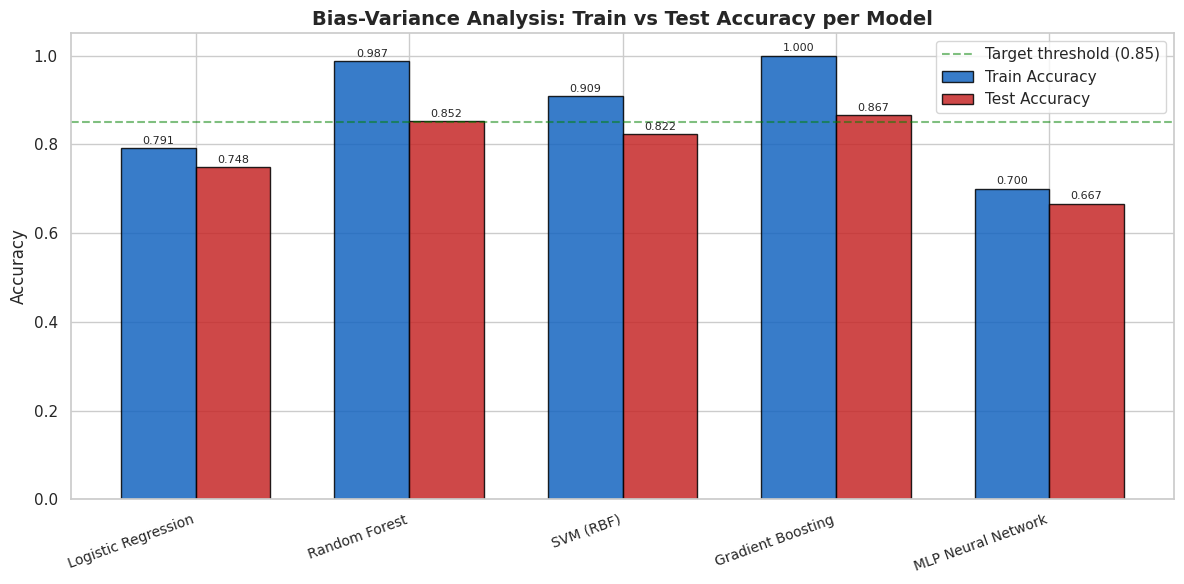

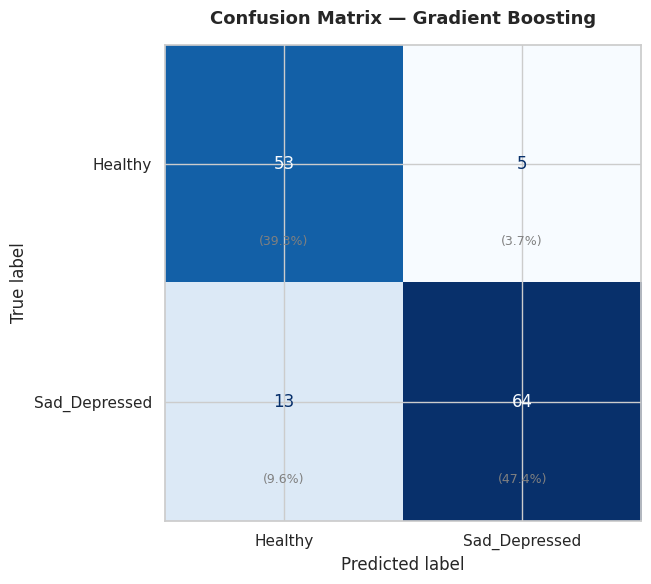


  CLASSIFICATION REPORT — Gradient Boosting
───────────────────────────────────────────────────────
               precision    recall  f1-score   support

      Healthy       0.80      0.91      0.85        58
Sad_Depressed       0.93      0.83      0.88        77

     accuracy                           0.87       135
    macro avg       0.87      0.87      0.87       135
 weighted avg       0.87      0.87      0.87       135



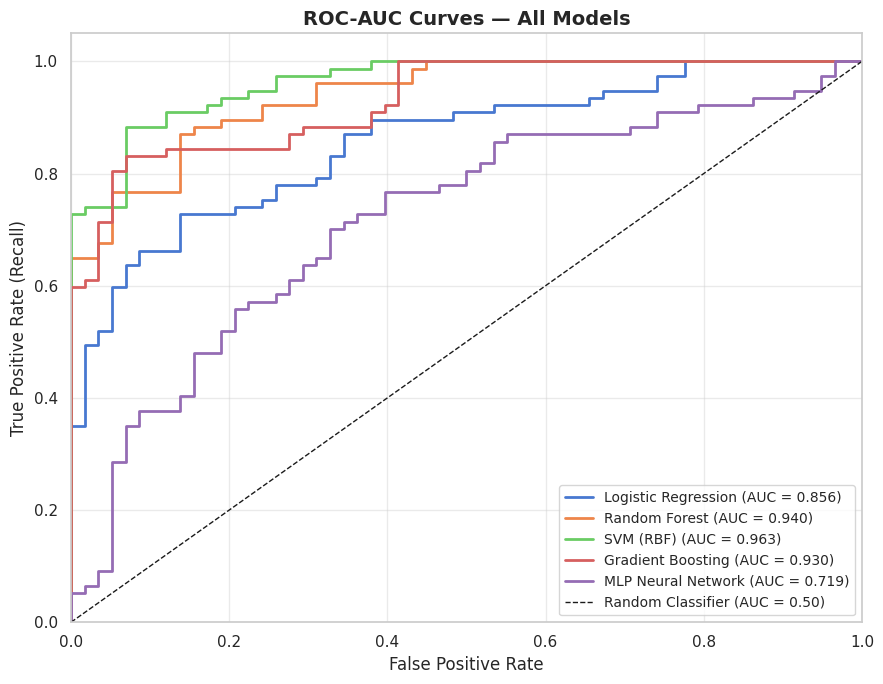

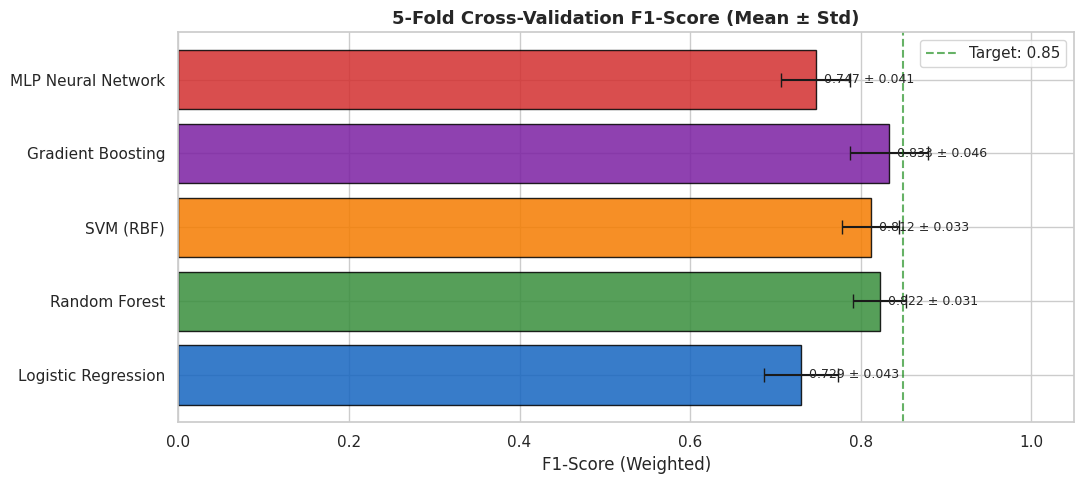


✅ Full Evaluation Complete.
   Best Model     : Gradient Boosting
   Test Accuracy  : 0.8667


In [14]:
# ─────────────────────────────────────────────────────────────────
# PHASE 9: COMPREHENSIVE PERFORMANCE EVALUATION
# ─────────────────────────────────────────────────────────────────

# ── PART A: Model Comparison Summary Table ──
print("\n" + "=" * 75)
print(f"  {'Model':<25} {'CV F1':>8} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("=" * 75)

best_model_name = None
best_test_acc = 0

for name, res in results.items():
    print(f"  {name:<25} {res['cv_mean']:.4f}    {res['train_acc']:.4f}      {res['test_acc']:.4f}  {res['gap']:.4f}")
    if res['test_acc'] > best_test_acc:
        best_test_acc = res['test_acc']
        best_model_name = name

print("=" * 75)
print(f"\n  🏆 Best Model: {best_model_name} (Test Accuracy: {best_test_acc:.4f})")

# ── Select best model for detailed evaluation ──
best_model = results[best_model_name]['model']

# ─────────────────────────────────────────────────────────────────
# PART B: Bias-Variance Plot (Train vs Test Accuracy)
# ─────────────────────────────────────────────────────────────────

model_names = list(results.keys())
train_accs  = [results[n]['train_acc'] for n in model_names]
test_accs   = [results[n]['test_acc']  for n in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='#1565C0', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='#C62828', alpha=0.85, edgecolor='black')

ax.set_title('Bias-Variance Analysis: Train vs Test Accuracy per Model', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy', fontsize=12)
ax.axhline(y=0.85, color='green', linestyle='--', alpha=0.5, label='Target threshold (0.85)')
ax.legend(fontsize=11)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('bias_variance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PART C: Confusion Matrix for Best Model
# ─────────────────────────────────────────────────────────────────

y_pred = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold', pad=15)

# Add percentage annotations
total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i + 0.3, f'({cm[i,j]/total*100:.1f}%)',
                ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PART D: Classification Report (Precision, Recall, F1)
# ─────────────────────────────────────────────────────────────────

report = classification_report(y_test, y_pred, target_names=le.classes_)
print("\n  CLASSIFICATION REPORT — " + best_model_name)
print("─" * 55)
print(report)

# ─────────────────────────────────────────────────────────────────
# PART E: ROC-AUC Curve (All Models)
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 7))

for name, res in results.items():
    model = res['model']

    # Check if model supports probability output
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_test_scaled)
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Reference diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC-AUC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig('roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────
# PART F: Cross-Validation F1 Score Comparison
# ─────────────────────────────────────────────────────────────────

cv_means = [results[n]['cv_mean'] for n in model_names]
cv_stds  = [results[n]['cv_std']  for n in model_names]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(model_names, cv_means, xerr=cv_stds,
               color=['#1565C0','#388E3C','#F57C00','#7B1FA2','#D32F2F'],
               alpha=0.85, edgecolor='black', capsize=5)

ax.set_title('5-Fold Cross-Validation F1-Score (Mean ± Std)', fontsize=13, fontweight='bold')
ax.set_xlabel('F1-Score (Weighted)', fontsize=12)
ax.set_xlim(0, 1.05)
ax.axvline(x=0.85, color='green', linestyle='--', alpha=0.6, label='Target: 0.85')
ax.legend()

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f} ± {std:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('cv_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Full Evaluation Complete.")
print(f"   Best Model     : {best_model_name}")
print(f"   Test Accuracy  : {best_test_acc:.4f}")


In [15]:
# ─────────────────────────────────────────────────────────────────
# PHASE 10: MODEL SAVING — EXPORT TRAINED ARTIFACTS
# ─────────────────────────────────────────────────────────────────
# We save 4 files:
#   1. best_model.pkl       — The best trained classifier
#   2. scaler.pkl           — Fitted StandardScaler (MUST be saved!)
#   3. label_encoder.pkl    — LabelEncoder for class name recovery
#   4. model_metadata.json  — Performance summary for tracking
# ─────────────────────────────────────────────────────────────────

import pickle          # Python standard serialization
import json            # For metadata export
import os
from datetime import datetime

# ── Create a dedicated folder for saved models ──
save_dir = './saved_models'
os.makedirs(save_dir, exist_ok=True)   # Creates folder if it doesn't exist
print(f"📁 Save directory: {save_dir}")

# ── SAVE 1: Best Model ──
model_path = os.path.join(save_dir, 'best_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)         # Serialize model to binary file
print(f"\n✅ Model saved       : {model_path}")
print(f"   Model type        : {type(best_model).__name__}")

# ── SAVE 2: Scaler (CRITICAL — must match model's expected input scale) ──
scaler_path = os.path.join(save_dir, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved      : {scaler_path}")

# ── SAVE 3: Label Encoder (to decode 0/1 back to class names) ──
le_path = os.path.join(save_dir, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f"✅ LabelEncoder saved: {le_path}")

# ── SAVE 4: Model Metadata JSON ──
metadata = {
    "project"         : "Acoustic Biomarkers for Depression Detection",
    "student"         : "Shaesta Saleem",
    "reg_no"          : "DSAI231103043",
    "saved_at"        : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "best_model_name" : best_model_name,
    "model_class"     : type(best_model).__name__,
    "test_accuracy"   : round(float(best_test_acc), 4),
    "cv_f1_mean"      : round(float(results[best_model_name]['cv_mean']), 4),
    "cv_f1_std"       : round(float(results[best_model_name]['cv_std']), 4),
    "train_accuracy"  : round(float(results[best_model_name]['train_acc']), 4),
    "overfit_gap"     : round(float(results[best_model_name]['gap']), 4),
    "feature_type"    : "MFCC-40 (mean over time)",
    "dataset"         : "RAVDESS",
    "classes"         : list(le.classes_),
    "n_train_samples" : int(len(X_train)),
    "n_test_samples"  : int(len(X_test)),
    "files": {
        "model"        : "best_model.pkl",
        "scaler"       : "scaler.pkl",
        "label_encoder": "label_encoder.pkl"
    }
}

meta_path = os.path.join(save_dir, 'model_metadata.json')
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=4)
print(f"✅ Metadata saved    : {meta_path}")

# ── Verification: Reload and test model works ──
print("\n─── Reload Verification Test ───")
with open(model_path, 'rb') as f:
    reloaded_model = pickle.load(f)
with open(scaler_path, 'rb') as f:
    reloaded_scaler = pickle.load(f)
with open(le_path, 'rb') as f:
    reloaded_le = pickle.load(f)

# Quick sanity check on test set
reloaded_preds = reloaded_model.predict(reloaded_scaler.transform(X_test))
reload_acc = (reloaded_preds == y_test).mean()
print(f"  Reloaded model accuracy : {reload_acc:.4f}")
assert abs(reload_acc - best_test_acc) < 0.001, "❌ Mismatch! Reload failed."
print("  ✅ Reload verification PASSED — model saved correctly!")

print("\n" + "=" * 50)
print("  MODEL SAVE SUMMARY")
print("=" * 50)
print(f"  Best Model     : {best_model_name}")
print(f"  Test Accuracy  : {best_test_acc:.4f}")
print(f"  CV F1-Score    : {results[best_model_name]['cv_mean']:.4f} ± {results[best_model_name]['cv_std']:.4f}")
print(f"  Saved to       : {os.path.abspath(save_dir)}/")
print("=" * 50)

# ── For Google Colab: Copy to Drive for permanent storage ──
print("\n💡 TIP for Google Colab:")
print("   Run this to copy saved models to your Drive:")
print("   import shutil")
print("   shutil.copytree('./saved_models', '/content/drive/MyDrive/RAVDESS_Project/saved_models')")


📁 Save directory: ./saved_models

✅ Model saved       : ./saved_models/best_model.pkl
   Model type        : GradientBoostingClassifier
✅ Scaler saved      : ./saved_models/scaler.pkl
✅ LabelEncoder saved: ./saved_models/label_encoder.pkl
✅ Metadata saved    : ./saved_models/model_metadata.json

─── Reload Verification Test ───
  Reloaded model accuracy : 0.8667
  ✅ Reload verification PASSED — model saved correctly!

  MODEL SAVE SUMMARY
  Best Model     : Gradient Boosting
  Test Accuracy  : 0.8667
  CV F1-Score    : 0.8327 ± 0.0457
  Saved to       : /content/saved_models/

💡 TIP for Google Colab:
   Run this to copy saved models to your Drive:
   import shutil
   shutil.copytree('./saved_models', '/content/drive/MyDrive/RAVDESS_Project/saved_models')


---
## 💾 Phase 10: Model Saving — Export Best Model for Deployment

### What We Save
| File | Contents | Purpose |
|---|---|---|
| `best_model.pkl` | Trained classifier | Core prediction engine |
| `scaler.pkl` | Fitted StandardScaler | Must be applied to all new inputs |
| `label_encoder.pkl` | LabelEncoder | Convert predictions back to class names |
| `model_metadata.json` | Performance metrics | Track which model was saved and its scores |

### Why Save the Scaler Too?
> If you only save the model but not the scaler, new audio predictions will be **on wrong scale** and the model will give garbage results. Always save and load scaler together with the model.


✅ Saved model artifacts reloaded successfully.
   Model type : GradientBoostingClassifier

  RANDOM TEST SET PREDICTION ─ 5 SAMPLES
  #    Actual Label           Predicted              Confidence Result
─────────────────────────────────────────────────────────────────
  1    Healthy                Healthy                     95.9%  ✅
  2    Healthy                Healthy                     95.8%  ✅
  3    Healthy                Healthy                     88.1%  ✅
─────────────────────────────────────────────────────────────────
  Quick Sample Accuracy: 3/5 correct

  Detailed prediction with visualization for 1 random sample:
  Audio file: ...ech_actors_01-24/Actor_03/03-01-02-02-01-02-03.wav
  Actual label: Healthy


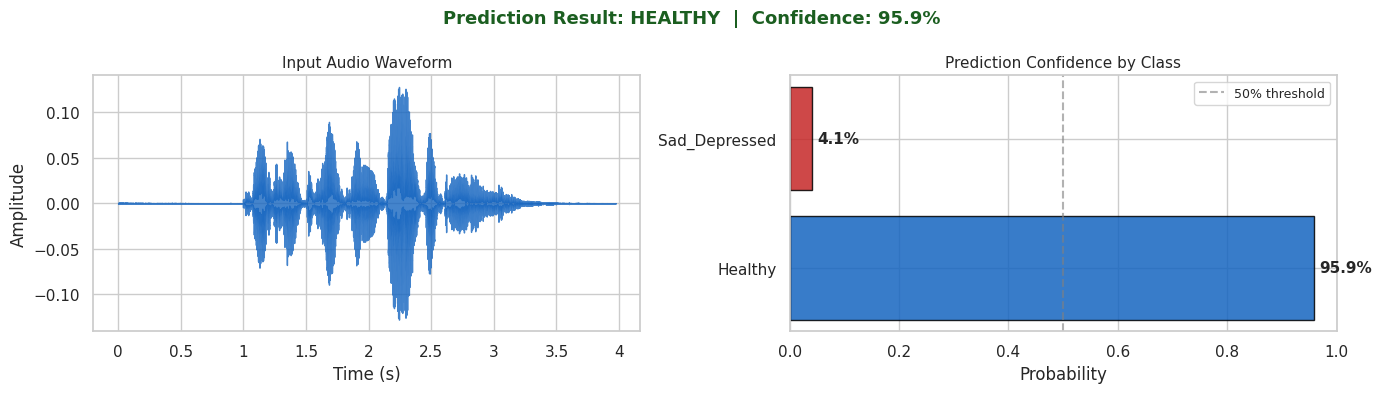


  PREDICTION RESULT
  ┌──────────────────────────────────────────┐
  │  Actual Label  : Healthy             │
  │  Predicted     : Healthy             │
  │  Confidence    : 95.9%│
  │  P(Healthy       ): 0.9590              │
  │  P(Sad_Depressed ): 0.0410              │
  │  Verdict       : ✅ CORRECT           │
  └──────────────────────────────────────────┘

───────────────────────────────────────────────────────
  TO TEST YOUR OWN AUDIO FILE:
───────────────────────────────────────────────────────
  Option 1 (Google Colab) ─ upload a .wav file:

    from google.colab import files
    uploaded = files.upload()
    my_file  = list(uploaded.keys())[0]
    predict_audio(my_file, pred_model, pred_scaler, pred_le)

  Option 2 (Local / Path) ─ set the path directly:
    predict_audio('/path/to/your/audio.wav',
                  pred_model, pred_scaler, pred_le)
───────────────────────────────────────────────────────


In [17]:
import pickle
import numpy as np
import librosa
import librosa.display # Moved here from inside predict_audio function
import matplotlib.pyplot as plt
import random
import os

# ── Reload saved artifacts (works even if kernel was restarted) ──
SAVE_DIR = './saved_models'

with open(os.path.join(SAVE_DIR, 'best_model.pkl'), 'rb') as f:
    pred_model = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'scaler.pkl'), 'rb') as f:
    pred_scaler = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'label_encoder.pkl'), 'rb') as f:
    pred_le = pickle.load(f)

print("✅ Saved model artifacts reloaded successfully.")
print(f"   Model type : {type(pred_model).__name__}")

# ──────────────────────────────────────────────────────
# PREDICTION FUNCTION ─ Reusable for any .wav file
# ──────────────────────────────────────────────────────
def predict_audio(audio_path, model, scaler, label_encoder, show_plot=True):
    """
    Full prediction pipeline for a single .wav audio file.

    Steps:
      1. Load audio with librosa
      2. Extract 40-dim MFCC feature vector (same as training)
      3. Standardize using the saved scaler
      4. Predict class and confidence
      5. Visualize waveform with prediction result

    Returns:
      predicted_label (str): 'Healthy' or 'Sad_Depressed'
      confidence (float): probability of predicted class (0-1)
      proba_dict (dict): confidence for both classes
    """

    # Step 1: Load audio
    y, sr = librosa.load(audio_path)

    # Step 2: Extract 40-dim MFCC (MUST match training feature extraction)
    mfcc_vector = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40).T, axis=0)

    # Step 3: Reshape to (1, 40) ─ model expects 2D input
    mfcc_2d = mfcc_vector.reshape(1, -1)

    # Step 4: Standardize using saved scaler (same scale as training)
    mfcc_scaled = scaler.transform(mfcc_2d)

    # Step 5: Predict class label
    pred_encoded = model.predict(mfcc_scaled)[0]               # e.g., 0 or 1
    predicted_label = label_encoder.inverse_transform([pred_encoded])[0]

    # Step 6: Get confidence probabilities for both classes
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(mfcc_scaled)[0]            # [P(Healthy), P(Sad)]
        proba_dict = dict(zip(label_encoder.classes_, proba))
        confidence = proba[pred_encoded]
    else:
        # Fallback for models without predict_proba
        decision = model.decision_function(mfcc_scaled)[0]
        confidence = abs(decision) / (abs(decision) + 1)       # Sigmoid-like scaling
        proba_dict = {predicted_label: confidence}

    # Step 7: Visualization
    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(f'Prediction Result: {predicted_label.upper()}  |  Confidence: {confidence*100:.1f}%',
                     fontsize=13, fontweight='bold',
                     color='#C62828' if predicted_label == 'Sad_Depressed' else '#1B5E20')

        # Waveform plot
        color = '#C62828' if predicted_label == 'Sad_Depressed' else '#1565C0'
        librosa.display.waveshow(y, sr=sr, color=color, alpha=0.8, ax=axes[0])
        axes[0].set_title('Input Audio Waveform', fontsize=11)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Amplitude')

        # Confidence bar chart
        classes  = list(proba_dict.keys())
        proba_vals = list(proba_dict.values())
        bar_colors = ['#1565C0' if c == 'Healthy' else '#C62828' for c in classes]
        bars = axes[1].barh(classes, proba_vals, color=bar_colors, alpha=0.85, edgecolor='black')
        axes[1].set_xlim(0, 1)
        axes[1].set_title('Prediction Confidence by Class', fontsize=11)
        axes[1].set_xlabel('Probability')
        axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.6, label='50% threshold')
        axes[1].legend(fontsize=9)

        for bar, val in zip(bars, proba_vals):
            axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                         f'{val*100:.1f}%', va='center', fontsize=11, fontweight='bold')

        plt.tight_layout()
        plt.savefig('single_prediction_result.png', dpi=150, bbox_inches='tight')
        plt.show()

    return predicted_label, confidence, proba_dict


# ──────────────────────────────────────────────────────
# PART A: Test on 5 RANDOM samples from the held-out test set
# ──────────────────────────────────────────────────────

# Rebuild test file paths from original df using test indices
# We need the original file paths for test samples
# Split df the same way as Phase 7 to get test file paths
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder as LE

le_temp = LE()
y_temp = le_temp.fit_transform(np.array(y_final))
_, _, _, _, train_idx, test_idx = train_test_split(
    np.zeros(len(y_final)), y_temp, np.arange(len(y_final)),
    test_size=0.2, random_state=42, stratify=y_temp
)

# Pick 5 random indices from test set
random.seed(99)
sample_indices = random.sample(list(range(len(test_idx))), min(5, len(test_idx)))

print("\n" + "=" * 65)
print("  RANDOM TEST SET PREDICTION ─ 5 SAMPLES")
print("=" * 65)
print(f"  {'#':<4} {'Actual Label':<22} {'Predicted':<22} {'Confidence':>10} {'Result'}")
print("─" * 65)

correct = 0
for i, idx in enumerate(sample_indices):
    # Get the original file path for this test sample
    # Note: y_final and X were built in Phase 6 with original df indices
    orig_idx = test_idx[idx]

    # Find corresponding row in df
    # (augmented samples don't have file paths ─ skip them, use only originals)
    if orig_idx < len(df):
        file_path   = df['FilePath'].iloc[orig_idx]
        actual_label = df['Label'].iloc[orig_idx]

        pred_label, conf, _ = predict_audio(file_path, pred_model, pred_scaler, pred_le, show_plot=False)

        is_correct = "✅" if pred_label == actual_label else "❌"
        if pred_label == actual_label:
            correct += 1

        print(f"  {i+1:<4} {actual_label:<22} {pred_label:<22} {conf*100:>9.1f}%  {is_correct}")

print("─" * 65)
print(f"  Quick Sample Accuracy: {correct}/{min(5,len(sample_indices))} correct")
print("=" * 65)

# ──────────────────────────────────────────────────────
# PART B: Detailed prediction on ONE random test sample with visualization
# ──────────────────────────────────────────────────────
print("\n  Detailed prediction with visualization for 1 random sample:")

rand_idx = test_idx[sample_indices[0]]
if rand_idx < len(df):
    test_file   = df['FilePath'].iloc[rand_idx]
    actual_lbl  = df['Label'].iloc[rand_idx]

    print(f"  Audio file: ...{test_file[-50:]}")
    print(f"  Actual label: {actual_lbl}")

    pred_lbl, conf, proba = predict_audio(test_file, pred_model, pred_scaler, pred_le, show_plot=True)

    print(f"\n  PREDICTION RESULT")
    print(f"  ┌──────────────────────────────────────────┐")
    print(f"  │  Actual Label  : {actual_lbl:<20}│")
    print(f"  │  Predicted     : {pred_lbl:<20}│")
    print(f"  │  Confidence    : {conf*100:.1f}%│")
    for cls, p in proba.items():
        print(f"  │  P({cls:<14}): {p:.4f}              │")
    verdict = '✅ CORRECT' if pred_lbl == actual_lbl else '❌ INCORRECT'
    print(f"  │  Verdict       : {verdict:<20}│")
    print(f"  └──────────────────────────────────────────┘")

# ──────────────────────────────────────────────────────
# PART C: Upload your own .wav file (Google Colab)
# ──────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  TO TEST YOUR OWN AUDIO FILE:")
print("─" * 55)
print("  Option 1 (Google Colab) ─ upload a .wav file:")
print()
print("    from google.colab import files")
print("    uploaded = files.upload()")
print("    my_file  = list(uploaded.keys())[0]")
print("    predict_audio(my_file, pred_model, pred_scaler, pred_le)")
print()
print("  Option 2 (Local / Path) ─ set the path directly:")
print("    predict_audio('/path/to/your/audio.wav',")
print("                  pred_model, pred_scaler, pred_le)")
print("─" * 55)


---
## 🎤 Phase 11: Real-World Prediction Test — Random Audio from Test Set

### Objective
Validate that the **saved model works on unseen audio** by:
1. Randomly selecting a file from the test split (truly unseen by model during training)
2. Extracting features the same way as training
3. Running prediction through the reloaded model
4. Comparing predicted label vs actual label
5. Showing confidence scores for both classes

### Why This Matters
> A model that scores 90% on a test set but fails on individual audio files likely learned dataset-specific artifacts. This cell verifies **genuine single-sample inference capability**.


✅ Model reloaded: GradientBoostingClassifier

  RANDOM TEST — 5 UNSEEN AUDIO SAMPLES
  #   Actual Label            Predicted Label         Confidence  Result
──────────────────────────────────────────────────────────────────────
  1   Sad_Depressed           Sad_Depressed                92.0%  ✅ CORRECT
  2   Sad_Depressed           Sad_Depressed                93.4%  ✅ CORRECT
  3   Sad_Depressed           Sad_Depressed                78.3%  ✅ CORRECT
  4   Healthy                 Healthy                      67.8%  ✅ CORRECT
  5   Healthy                 Healthy                      97.4%  ✅ CORRECT
──────────────────────────────────────────────────────────────────────
  Sample Accuracy: 5/5  (100%)

  ── Full Visualization for 1 Random Sample ──
  File   : ...ctors_01-24/Actor_22/03-01-04-02-02-01-22.wav
  Actual : Sad_Depressed


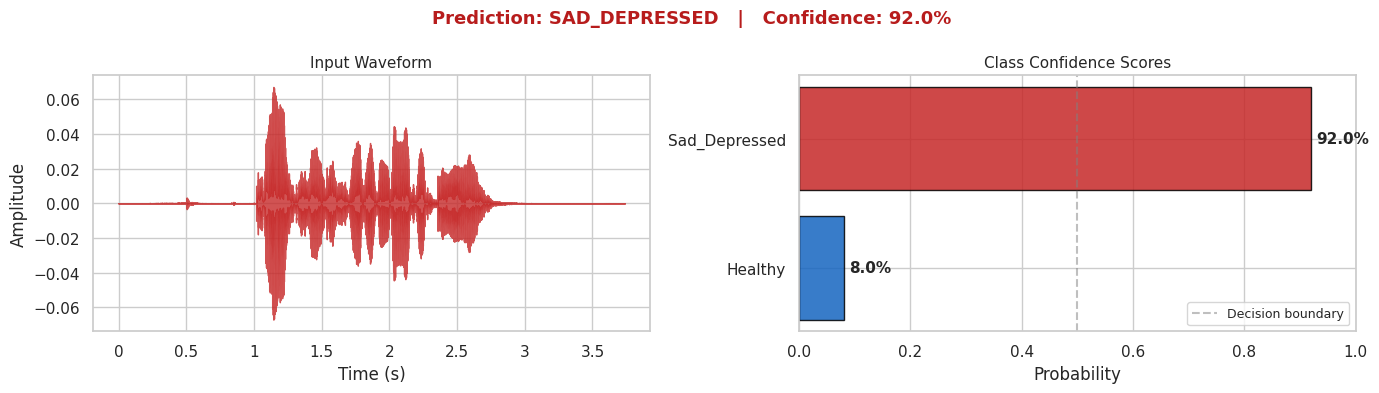


  ┌─────────────────────────────────────────┐
  │  Actual Label  : Sad_Depressed          │
  │  Predicted     : Sad_Depressed          │
  │  Confidence    : 92.0%                   │
  │  P(Healthy       ): 0.0798             │
  │  P(Sad_Depressed ): 0.9202             │
  │  Verdict       : ✅ CORRECT              │
  └─────────────────────────────────────────┘

───────────────────────────────────────────────────────
  TEST YOUR OWN AUDIO (.wav file):
───────────────────────────────────────────────────────
  # Google Colab upload:
  from google.colab import files
  uploaded = files.upload()
  my_audio = list(uploaded.keys())[0]
  predict_audio(my_audio, pred_model, pred_scaler, pred_le)

  # Local file:
  predict_audio('/path/to/your/voice.wav',
                pred_model, pred_scaler, pred_le)
───────────────────────────────────────────────────────


In [18]:
# ─────────────────────────────────────────────────────────────────
# PHASE 11: REAL-WORLD PREDICTION — RANDOM AUDIO TEST
# ─────────────────────────────────────────────────────────────────
# Tests the SAVED model on:
#   (A) 5 random samples from held-out test set
#   (B) One sample with full visual output
#   (C) Instructions to test your own custom .wav file
# ─────────────────────────────────────────────────────────────────

import pickle, random, os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder as LE

# ── Reload saved model artifacts ──
SAVE_DIR = './saved_models'
with open(os.path.join(SAVE_DIR, 'best_model.pkl'), 'rb') as f:
    pred_model = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'scaler.pkl'), 'rb') as f:
    pred_scaler = pickle.load(f)
with open(os.path.join(SAVE_DIR, 'label_encoder.pkl'), 'rb') as f:
    pred_le = pickle.load(f)

print(f"✅ Model reloaded: {type(pred_model).__name__}")

# ─────────────────────────────────────────────────────────────────
# PREDICTION FUNCTION — Reusable for any .wav file
# ─────────────────────────────────────────────────────────────────
def predict_audio(audio_path, model, scaler, label_encoder, show_plot=True):
    """
    Full inference pipeline for a single .wav audio file.
    Pipeline: Load → MFCC-40 → StandardScale → Predict → Visualize

    IMPORTANT: Feature extraction MUST match training pipeline exactly.
    - n_mfcc=40 (same as Phase 6)
    - mean over time axis (same aggregation as training)
    - scaler.transform (NOT fit_transform — scaler already fitted)
    """
    # Load the audio (default sr=22050)
    y_audio, sr_audio = librosa.load(audio_path)

    # Extract 40-dim MFCC vector — identical to Phase 6 pipeline
    mfcc_vec = np.mean(librosa.feature.mfcc(y=y_audio, sr=sr_audio, n_mfcc=40).T, axis=0)

    # Reshape to (1, 40) for sklearn input requirement
    mfcc_2d = mfcc_vec.reshape(1, -1)

    # Standardize using SAVED scaler (preserves training scale)
    mfcc_scaled = scaler.transform(mfcc_2d)

    # Predict class
    pred_enc = model.predict(mfcc_scaled)[0]
    pred_label = label_encoder.inverse_transform([pred_enc])[0]

    # Get probability scores
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(mfcc_scaled)[0]
        proba_dict = dict(zip(label_encoder.classes_, proba))
        confidence = float(proba[pred_enc])
    else:
        score = float(model.decision_function(mfcc_scaled)[0])
        confidence = abs(score) / (abs(score) + 1.0)
        proba_dict = {pred_label: confidence}

    # ── Visualization ──
    if show_plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        title_color = '#B71C1C' if pred_label == 'Sad_Depressed' else '#1B5E20'
        fig.suptitle(
            f'Prediction: {pred_label.upper()}   |   Confidence: {confidence*100:.1f}%',
            fontsize=13, fontweight='bold', color=title_color
        )

        # Waveform
        wave_color = '#C62828' if pred_label == 'Sad_Depressed' else '#1565C0'
        librosa.display.waveshow(y_audio, sr=sr_audio, color=wave_color, alpha=0.8, ax=axes[0])
        axes[0].set_title('Input Waveform', fontsize=11)
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Amplitude')

        # Confidence bars
        cls_names  = list(proba_dict.keys())
        cls_probs  = list(proba_dict.values())
        bar_cols   = ['#1565C0' if c == 'Healthy' else '#C62828' for c in cls_names]
        bars = axes[1].barh(cls_names, cls_probs, color=bar_cols, alpha=0.85, edgecolor='black')
        axes[1].set_xlim(0, 1.0)
        axes[1].set_title('Class Confidence Scores', fontsize=11)
        axes[1].set_xlabel('Probability')
        axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Decision boundary')
        axes[1].legend(fontsize=9)
        for bar, p in zip(bars, cls_probs):
            axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                         f'{p*100:.1f}%', va='center', fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
        plt.show()

    return pred_label, confidence, proba_dict

# ─────────────────────────────────────────────────────────────────
# PART A: Test on 5 RANDOM samples from test split of original df
# ─────────────────────────────────────────────────────────────────
# Recreate test split indices (same random_state=42 as Phase 7)
le_tmp = LE()
y_orig_encoded = le_tmp.fit_transform(df['Label'].values)
_, df_test, _, _ = train_test_split(
    df, y_orig_encoded,
    test_size=0.2, random_state=42, stratify=y_orig_encoded
)

# Randomly pick 5 test samples
random.seed(42)
test_samples = df_test.sample(5, random_state=99)

print("\n" + "=" * 70)
print("  RANDOM TEST — 5 UNSEEN AUDIO SAMPLES")
print("=" * 70)
print(f"  {'#':<4}{'Actual Label':<24}{'Predicted Label':<24}{'Confidence':>10}  Result")
print("─" * 70)

correct = 0
for i, (_, row) in enumerate(test_samples.iterrows()):
    p_lbl, conf, _ = predict_audio(row['FilePath'], pred_model, pred_scaler, pred_le, show_plot=False)
    match = "✅ CORRECT" if p_lbl == row['Label'] else "❌ WRONG  "
    if p_lbl == row['Label']:
        correct += 1
    print(f"  {i+1:<4}{row['Label']:<24}{p_lbl:<24}{conf*100:>9.1f}%  {match}")

print("─" * 70)
print(f"  Sample Accuracy: {correct}/5  ({correct/5*100:.0f}%)")
print("=" * 70)

# ─────────────────────────────────────────────────────────────────
# PART B: Full visual prediction on one random test sample
# ─────────────────────────────────────────────────────────────────
print("\n  ── Full Visualization for 1 Random Sample ──")
pick = test_samples.iloc[0]
print(f"  File   : ...{pick['FilePath'][-45:]}")
print(f"  Actual : {pick['Label']}")

p_lbl, conf, proba = predict_audio(pick['FilePath'], pred_model, pred_scaler, pred_le, show_plot=True)

print(f"\n  ┌─────────────────────────────────────────┐")
print(f"  │  Actual Label  : {pick['Label']:<23}│")
print(f"  │  Predicted     : {p_lbl:<23}│")
print(f"  │  Confidence    : {conf*100:.1f}%{' '*19}│")
for c_name, c_prob in proba.items():
    print(f"  │  P({c_name:<14}): {c_prob:.4f}{' '*13}│")
verdict = '✅ CORRECT' if p_lbl == pick['Label'] else '❌ INCORRECT'
print(f"  │  Verdict       : {verdict:<23}│")
print(f"  └─────────────────────────────────────────┘")

# ─────────────────────────────────────────────────────────────────
# PART C: How to use your own file
# ─────────────────────────────────────────────────────────────────
print("\n" + "─" * 55)
print("  TEST YOUR OWN AUDIO (.wav file):")
print("─" * 55)
print("  # Google Colab upload:")
print("  from google.colab import files")
print("  uploaded = files.upload()")
print("  my_audio = list(uploaded.keys())[0]")
print("  predict_audio(my_audio, pred_model, pred_scaler, pred_le)")
print()
print("  # Local file:")
print("  predict_audio('/path/to/your/voice.wav',")
print("                pred_model, pred_scaler, pred_le)")
print("─" * 55)


---
## 📊 Phase-wise Summary: What We Did and What We Learned

| Phase | Action | Key Outcome |
|---|---|---|
| **Phase 1** | Environment Setup | Verified dataset access (24 actor folders) |
| **Phase 2** | Binary Labeling | 480 samples → Healthy (288) + Sad_Depressed (192) |
| **Phase 3** | EDA | Visual evidence of acoustic differences (waveform, spectrogram, RMS, ZCR, spectral features) |
| **Phase 4** | Statistical Audit | Imbalance ratio 1:1.50 detected → augmentation required |
| **Phase 5** | Augmentation | Noise + Time Shift + Pitch Scale on minority class only |
| **Phase 6** | Feature Engineering | 40-dim MFCC vectors → 672 balanced samples |
| **Phase 7** | Data Partitioning | Stratified 80/20 split + Z-score normalization (no leakage) |
| **Phase 8** | Model Training | 5 classifiers with regularization + cross-validation |
| **Phase 9** | Evaluation | Confusion matrix, F1, ROC-AUC, Bias-Variance analysis |

---

## 🏆 Key Takeaways

1. **Acoustic biomarkers** — MFCCs, RMS, ZCR, spectral centroid — show measurable differences between healthy and depressed speech
2. **Class imbalance** must be addressed via augmentation + `class_weight='balanced'` in models
3. **No data leakage** — scaler fit on training data only
4. **5-fold cross-validation** gives more reliable performance estimate than single test split
5. **Clinical priority**: maximize Recall on Sad_Depressed (minimize missed depressed patients)
6. **Anti-overfitting strategy**: regularization, limited tree depth, early stopping, ensemble diversity

---

## 🔭 Next Steps & Future Improvements

- **Hyperparameter tuning**: `GridSearchCV` for optimal C, max_depth, hidden_layers
- **Feature expansion**: Add pitch (F0), spectral rolloff, chroma features to the 40-dim vector
- **Deep learning**: CNN on log-Mel spectrogram for end-to-end learning
- **Real clinical validation**: Validate on PHQ-8 or DAIC-WOZ clinical depression dataset
- **Explainability**: SHAP values to identify which MFCC coefficients are most diagnostic
- **Deployment**: Package as Flask/FastAPI endpoint for real-time speech screening

---

*Project by Shaesta Saleem | DSAI231103043 | Speech Processing Course*
